In [ ]:
import sys
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic

import cv2
from PIL import Image


In [2]:
def show_img(img, title=None, cmap=None, bgr=False, title_size=8, ax=None, figsize=None):
    if 'torch' in sys.modules and torch.is_tensor(img):
        if len(img.shape)==2: img= img.unsqueeze(dim=0)
        img = img.permute(1, 2, 0)
    fig = None
    if ax is None:
        fig = plt.figure(figsize=figsize)#, dpi=72)
        ax = axs = fig.subplots(1, 1)
    ax.axis('off')
    STYLE_PLOT_TITLE= {'fontsize': title_size }
    if title: ax.set_title(title, **STYLE_PLOT_TITLE)
    if cmap is None:
        cmap = 'gray' if len(img.shape)==2 else None
    if bgr and len(img.shape)==3 and img.shape[2]==3:
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img, cmap=cmap)
    if fig is not None:
        plt.show()
    return ax

#imgs: [array(H,W)[:int32]]
def show_imgs(imgs, titles=None, cmap=None, ncols=None, nrows=None, bgr=False, title_size=4, figsize=None, pad=0):
    if isinstance(imgs, list):
        imgs = np.array(imgs)
    n = imgs.shape[0]
    if ncols==None:
        if nrows==None:
            ncols=1
        else:
            ncols=int(n/nrows) + (n % nrows > 0)
    if nrows==None:
        nrows=n//ncols + int(n% ncols!=0)
    fig = plt.figure(figsize=figsize) #, dpi=72)
    axs = fig.subplots(nrows, ncols)
    if nrows>1 or ncols>1:
        axs = axs.flatten()
    else:
        axs = [axs]
    plt.subplots_adjust(top=1-pad, bottom=0+pad, left=0+pad, right=1-pad, wspace=pad, hspace=pad) 
    #print('!!',nrows, ncols, axs)
    for ax in axs:
        ax.axis('off')
        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.tick_params(left=False)
    for i in range(imgs.shape[0]):
        img = imgs[i] 
        if cmap is None:
            cmap_ = 'gray' if len(img.shape)==2 else None
        else:
            cmap_ = cmap[i] if isinstance(cmap, list) else cmap
        if bgr and len(img.shape)==3 and img.shape[2]==3:
            img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap=cmap_)
        STYLE_PLOT_TITLE= {'fontsize': title_size }
        if titles and i<len(titles):
            axs[i].set_title(str(titles[i]), **STYLE_PLOT_TITLE)
    plt.show()
    return axs

    
def cv_bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
SEED=37
random.seed(SEED)
np.random.seed(SEED)
np.set_printoptions(edgeitems=3, infstr='inf', linewidth=120, nanstr='nan', precision=4, suppress=False, threshold=1000, formatter=None)


In [4]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data        # shape (70000, 784)
y = mnist.target     # labels as strings



(70000, 784) (70000,)
(70000, 28, 28) (70000,)


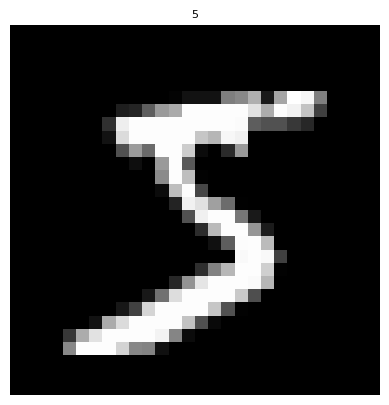

<Axes: title={'center': '5'}>

In [40]:
print(X.shape, y.shape)
y_ = y.astype(int) # Convert labels to int
X_ = X.reshape(-1, 28, 28)
print(X_.shape, y.shape)
show_img(X_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)



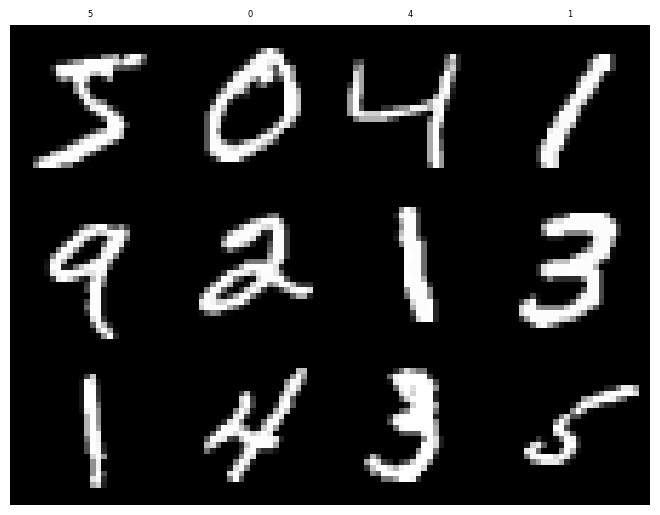

array([<Axes: title={'center': '5'}>, <Axes: title={'center': '0'}>,
       <Axes: title={'center': '4'}>, <Axes: title={'center': '1'}>,
       <Axes: title={'center': '9'}>, <Axes: title={'center': '2'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '3'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '4'}>,
       <Axes: title={'center': '3'}>, <Axes: title={'center': '5'}>],
      dtype=object)

In [5]:
show_imgs(X_[:12], titles=y[:12].tolist(), ncols=4, nrows=None, title_size=6, figsize=None, pad=0)


(70000, 28, 28)
(3, 3, 9, 9)
(3, 3, 9, 9) (9, 9, 9) (9, 81)


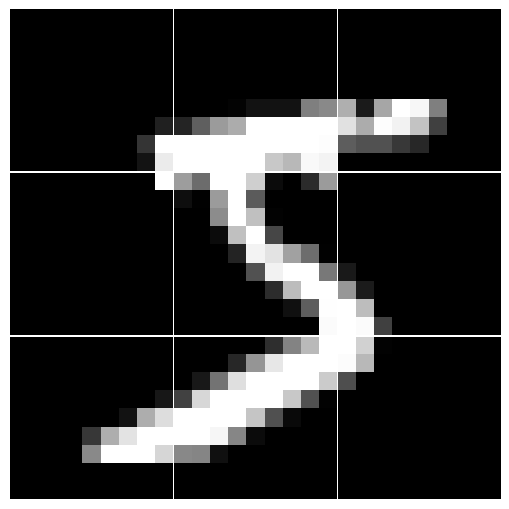

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

def tiles(a, K, S):
    tiles = sliding_window_view(a, (K, K))
    return tiles[::S, ::S]

print(X_.shape)

Xs=tiles(X_[0], K=9, S=9)
print(Xs.shape)

Xs_ = Xs.reshape(-1, *Xs.shape[2:])
Xs__ = Xs_.reshape(Xs_.shape[0], -1)
print(Xs.shape, Xs_.shape, Xs__.shape)
show_imgs(Xs_, titles=None, ncols=Xs.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)





(784,) int64
(784, 784)


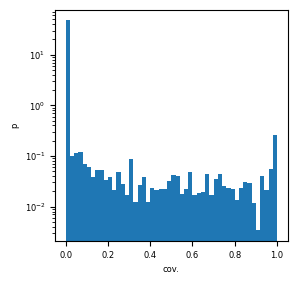

In [143]:
Xf = X.astype(float)/255
print(X[0].shape, X.dtype)
C = np.outer(Xf[0], Xf[0])
print(C.shape)
#for T in np.linspace(0, .1, num=22):
#    print(T, C.shape[0]*C.shape[0], np.sum(C>=T))

def hist_cov(C, title=None, title_size=6,  ax=None, figsize=(1*3,1*3)):
    fig = None
    if ax is None:
        fig = plt.figure(figsize=figsize) #, dpi=72)
        axs = fig.subplots(1, 1)
        ax = axs
    STYLE_PLOT_TITLE= {'fontsize': title_size }
    if title:
        ax.set_title(title, **STYLE_PLOT_TITLE)
    C_ = C.flatten()
    ax.hist(C_, bins=50, density=True)
    ax.set_xlabel("cov.", fontsize=6)
    ax.set_ylabel("p", fontsize=6)
    ax.set_yscale("log")
    ax.tick_params(axis='both', labelsize=6)
    if fig is not None:
        plt.show()

hist_cov(C)


(784,) (784, 784)
(16, 784)
(16, 28, 28)


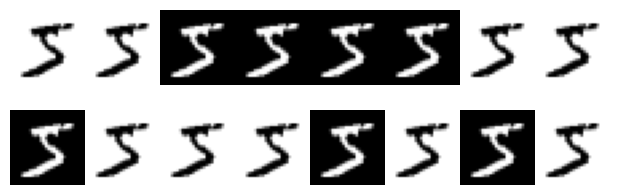

In [9]:
m = np.zeros(C.shape[0]) + .5
print(m.shape, C.shape)
x = np.random.multivariate_normal(m, C*20, 16)
print(x.shape)
x_ = x.reshape(-1, 28, 28)
print(x_.shape)
x__ = x_*255
#show_img(x__[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
_=show_imgs(x__, titles=y[:0].tolist(), ncols=8, nrows=None, title_size=6, figsize=(6*1, 2*1), pad=0)
#print(x_[0][14])
#print(x_[1][14])
#print(x__[0][14])
#print(x__[1][14])


(70000, 784) (70000, 28, 28) (70000,)


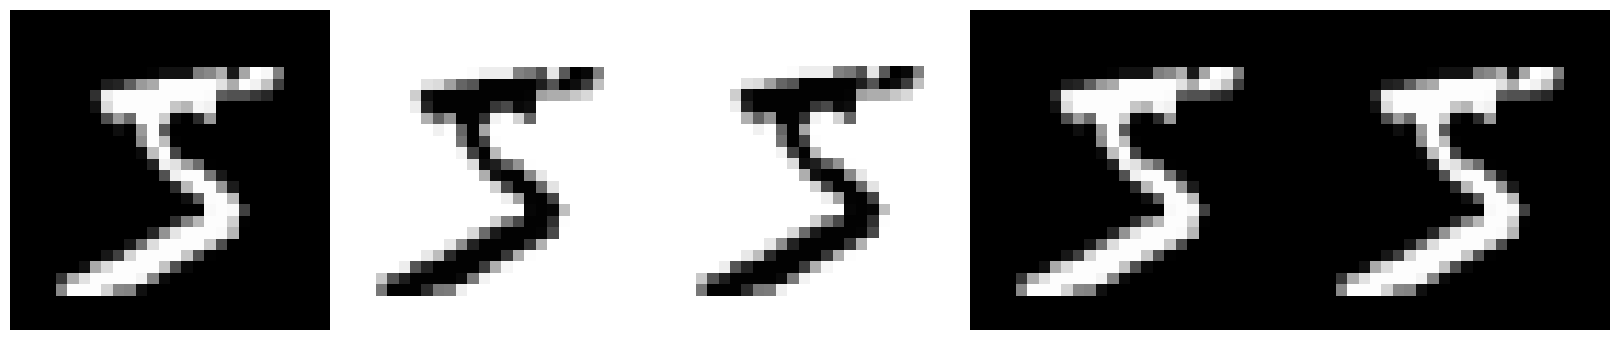

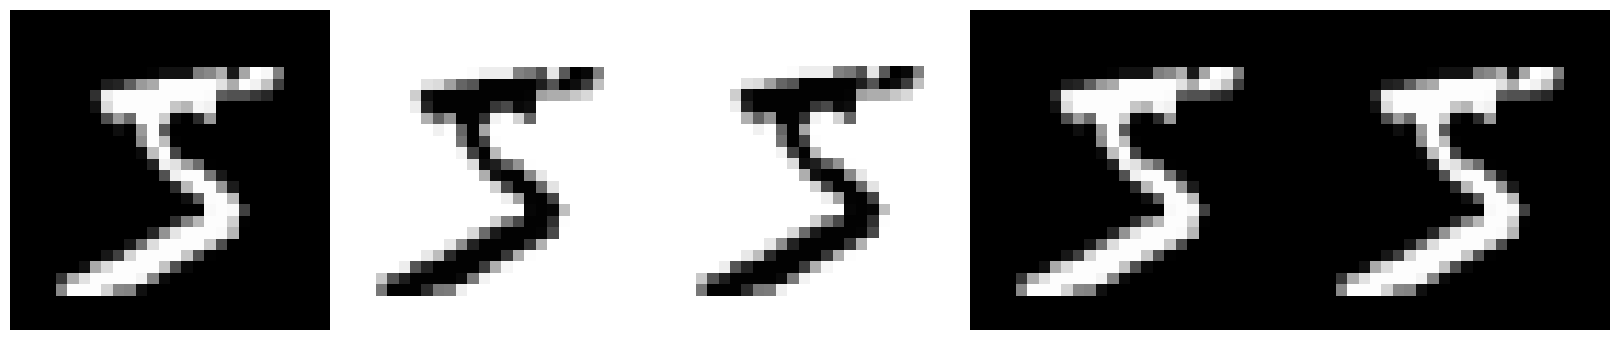

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.31764706 0.94117647 0.99215686 0.99215686 0.46666667
 0.09803922 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[  0   0   0   0   0   0   0   0   0   0   0   0   0  81 240 253 253 119
  25   0   0   0   0   0   0   0   0   0]
0 [ 0.50000067  0.49999984  0.49999984  0.50000008  0.49999985  0.50000049
  0.50000077  0.49999979  0.50000026  0.5000002   0.49999974  0.49999973
  0.4999997  -1.72090663 -6.08046701 -6.4369084  -6.43690841 -2.76281441
 -0.18546487  0.49999903  0.49999929  0.49999952  0.50000042  0.49999998
  0.50000009  0.50000008  0.49999999  0.49999956]
0 [  127.50016963   127.49995958   127.49995797   127.50002142
   127.49996127   127.50012603   127.50019721   127.49994702
   127.50006539   127.50004974   127.49993493   127.49993214
   127.49992327  -438.8311902  -1550.51908869 -1641.41164195
 -164

In [10]:
Xf_ = Xf.reshape(-1, 28, 28)
print(Xf.shape, Xf_.shape, y.shape)
_=show_imgs([Xf_[0], x_[0], x_[1], x_[2],x_[3]], ncols=5, figsize=(4*4, 1*4))
_=show_imgs([X_[0], x__[0], x__[1], x__[2],x__[3]], ncols=5, figsize=(4*4, 1*4))
print(Xf_[0,14])
print(X_[0,14])
for i in range(0, 2):
    print(i, x_[i,14])
    print(i, x__[i,14])



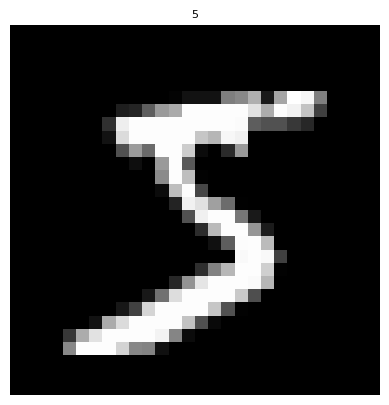

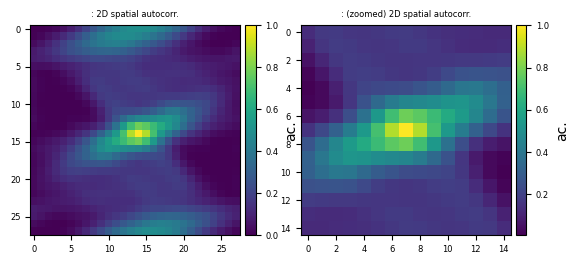

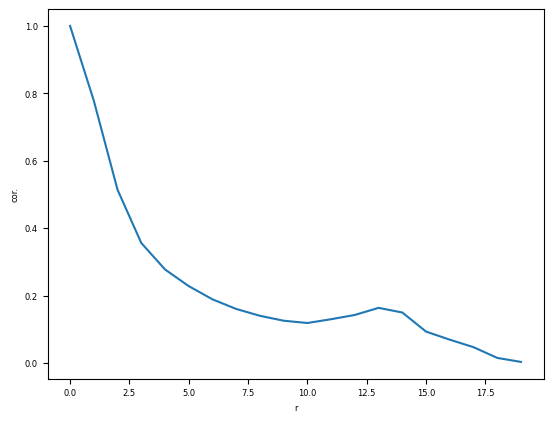

In [91]:
def autocorr2d_fft(img, normalize=True):
    F = np.fft.fft2(img)
    S = np.abs(F)**2
    C = np.fft.ifft2(S).real
    ac2d = np.fft.fftshift(C)  # center at zero displacement
    if normalize:
        ac2d = ac2d/ac2d[img.shape[0]//2, img.shape[1]//2]
    return ac2d

def autocorr_radial_(C):
    ny, nx = C.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny // 2, nx // 2
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    tbin = np.bincount(r.ravel(), C.ravel())
    nr = np.bincount(r.ravel())
    acr = tbin / nr
    return acr

def autocorr_radial(img, normalize=True):
    ac2d = autocorr2d_fft(img, normalize=False)
    acr = autocorr_radial_(ac2d)
    if normalize:
        acr /= acr[0]
    return acr


def autocorr_radial2(f, max_r):
    h, w = f.shape
    C = np.zeros(max_r)
    N = np.zeros(max_r)

    for y in range(h):
        for x in range(w):
            for dy in range(-max_r, max_r+1):
                for dx in range(-max_r, max_r+1):
                    r = int(np.sqrt(dx*dx + dy*dy))
                    if r < max_r:
                        y2, x2 = y+dy, x+dx
                        if 0 <= y2 < h and 0 <= x2 < w:
                            C[r] += f[y, x] * f[y2, x2]
                            N[r] += 1
    return C / N

from mpl_toolkits.axes_grid1 import make_axes_locatable

def show_autocorr2d(ac2d, title='', axs=None, axi=0, figsize=None):
    fig = None
    if axs is None:
        fig = plt.figure(figsize=figsize) #, dpi=72)
        axs = fig.subplots(1, 2)
    ax0 = axs[axi]
    im0 = ax0.imshow(ac2d)
    div0 = make_axes_locatable(ax0)
    cax0 = div0.append_axes('right', size='5%', pad=0.05)
    cbar0 = ax0.get_figure().colorbar(im0, cax=cax0, orientation='vertical', label="ac.")
    cbar0.ax.tick_params(labelsize=6)
    ax0.set_title(f"{title}: 2D spatial autocorr.", fontsize=6)
    ax0.tick_params(axis='both', labelsize=6)
    ny, nx = ac2d.shape
    cy, cx = ny // 2, nx // 2
    R = min(ny, nx)//4  # radius in pixels
    ac2d_ = ac2d[cy-R:cy+R+1, cx-R:cx+R+1]
    ax1 = axs[axi+1]
    im1 = ax1.imshow(ac2d_)
    div1 = make_axes_locatable(ax1)
    cax1 = div1.append_axes('right', size='5%', pad=0.05)
    cbar1 = ax1.get_figure().colorbar(im1, cax=cax1, orientation='vertical', label="ac.")
    cbar1.ax.tick_params(labelsize=6)
    ax1.set_title(f"{title}: (zoomed) 2D spatial autocorr.", fontsize=6)
    ax1.tick_params(axis='both', labelsize=6)
    if fig is not None:
        plt.show()
    
def compute_show_autocorr2d(img, normalize=True, title='', axs=None, axi=0, figsize=None):
    ac2d = autocorr2d_fft(img, normalize=normalize)
    show_autocorr2d(ac2d, title=title, axs=axs, axi=axi, figsize=figsize)
    return ac2d

def show_autocorr_radial(acr, title=None, title_size=6, ax=None, figsize=None):
    fig = None
    if ax is None:
        fig = plt.figure(figsize=figsize) #, dpi=72)
        ax = axs = fig.subplots(1, 1)
    #print(acr)
    if title:
        STYLE_PLOT_TITLE= {'fontsize': title_size }
        ax.set_title(title, **STYLE_PLOT_TITLE)
    ax.plot(acr)
    ax.set_xlabel("r", fontsize=6)
    ax.set_ylabel("cor.", fontsize=6)
    ax.tick_params(axis='both', labelsize=6)
    if fig is not None:
        plt.show()
    
def compute_show_autocorr_radial(img, title=None, title_size=6, ax=None, figsize=None):
    acr = autocorr_radial(img)
    #acr2 = autocorr_radial2(img, img.shape[1])
    show_autocorr_radial(acr, title=title, title_size=title_size, ax=ax, figsize=figsize)

show_img(Xf_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
ac2d = autocorr2d_fft(Xf_[0], normalize=True)
show_autocorr2d(ac2d)
acr = autocorr_radial(Xf_[0])
show_autocorr_radial(acr)
#acr2 = autocorr_radial2(Xf_[0], Xf_.shape[1])
#show_autocorr_radial(acr2)

#print(Xf_[0,14])
#print(ac2d.shape)
#print(acr.shape)
#print(acr2.shape)
#print(ac2d[14])
#print(acr)
#print(acr2)


In [165]:
a = np.arange(4).reshape((2,2))
#b = np.arange(4).reshape((2,3,4))

print(a.shape)
print(a)
c = np.kron(a,a)
#show_img(c)
print(c.shape)
print(c)
a_ = a.flatten()
C = np.outer(a_, a_)
C4 = C.reshape(a.shape[0], a.shape[1], a.shape[0], a.shape[1])
C2 = C4.reshape(a.shape[0]*a.shape[0], a.shape[1]*a.shape[1])
print('C2:')
print(C2)
print('--')
x = a.ravel()
C_outer = np.outer(x, x)
print('C_outer:')
print(C_outer)
C_kron = np.kron(a, a)
print('C_kron:')
print(C_kron)
C_kron_ = C_kron.reshape(a.shape[0]*a.shape[1], a.shape[0]*a.shape[1]).T  # up to permutation
print('C_kron_:')
print(C_kron_)
print(np.allclose(C_outer, C_kron_))
C2 = np.outer(x, x).reshape(a.shape[0]*a.shape[1], a.shape[0]*a.shape[1]).reshape(a.shape[0]*a.shape[0], a.shape[1]*a.shape[1])
print('C2:')
print(C2)
print(np.allclose(C2, np.kron(a, a)))


(2, 2)
[[0 1]
 [2 3]]
(4, 4)
[[0 0 0 1]
 [0 0 2 3]
 [0 2 0 3]
 [4 6 6 9]]
C2:
[[0 0 0 0]
 [0 1 2 3]
 [0 2 4 6]
 [0 3 6 9]]
--
C_outer:
[[0 0 0 0]
 [0 1 2 3]
 [0 2 4 6]
 [0 3 6 9]]
C_kron:
[[0 0 0 1]
 [0 0 2 3]
 [0 2 0 3]
 [4 6 6 9]]
C_kron_:
[[0 0 0 4]
 [0 0 2 6]
 [0 2 0 6]
 [1 3 3 9]]
False
C2:
[[0 0 0 0]
 [0 1 2 3]
 [0 2 4 6]
 [0 3 6 9]]
False


(28, 28)
a: (28, 28) C: (784, 784) C4: (28, 28, 28, 28) C2: (784, 784) Kron: (784, 784)


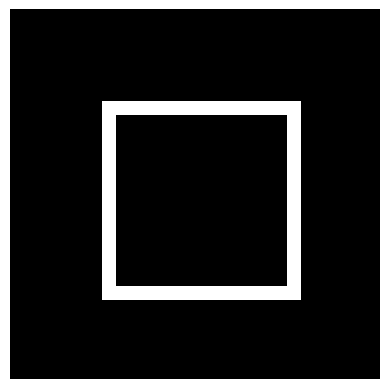

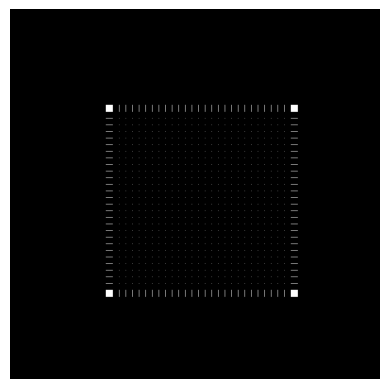

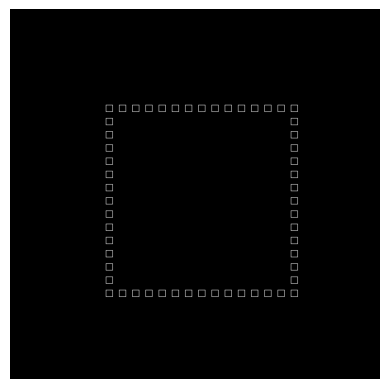

In [189]:
def img_cov(a, rescale=False):
    if rescale:
        a = a.copy().astype(float)/255
    a_ = a.flatten()
    A = np.outer(a_, a_)
    return A 

def img_kron(a, rescale=False):
    if rescale:
        a = a.copy().astype(float)/255
    A = np.kron(a, a)
    return A 

def show_img_cov(C, rescale=False, title=None, title_size=6, ax=None, figsize=None):
    if rescale:
        C = (C*255).astype(int)
    show_img(C, title=title, title_size=title_size, ax=ax, figsize=figsize)

def show_img_kron(C, rescale=False, title=None, title_size=6, ax=None, figsize=None):
    if rescale:
        C = (C*255).astype(int)
    show_img(C, title=title, title_size=title_size, ax=ax, figsize=figsize)

def compute_show_img_kron(img, rescale=False, title=None, title_size=6, ax=None, figsize=None):
    C = img_kron(img, rescale=rescale)
    show_img_kron(C, title=title, title_size=title_size, ax=ax, figsize=figsize)

    
a = make_glyph(12, dx=0, dy=0, sx= 1, sy=1, rot=0)
print(a.shape)
C = img_cov(a)
C4 = C.reshape(a.shape[0], a.shape[1], a.shape[0], a.shape[1])
C2 = C4.reshape(a.shape[0]*a.shape[0], a.shape[1]*a.shape[1])
kaa = np.kron(a, a)
print('a:', a.shape, 'C:', C.shape, 'C4:', C4.shape,  'C2:', C2.shape, 'Kron:', kaa.shape)
#show_img(kaa)
#print(A.sum(), A.max())
#A = img_cov(a)
#C2_ = C2.reshape()
show_img(a)
#show_img(C2)
compute_show_img_cov(a)
compute_show_img_kron(a)



In [190]:
def xshow_img(img, title=f'', cmap=None, bgr=False, title_size=8, axs=None, figsize=None,
    imshow =True, cov_histo=True, ac2d=True, acr=True, cov=True, kron=True):
    fig = None
    ncols = imshow + cov_histo + ac2d*2 + acr + cov + kron
    if axs is None:
        if figsize is None:
            figsize = (ncols*3, 1*3)
        fig = plt.figure(figsize=figsize) #, dpi=72)
        axs = fig.subplots(1, ncols)
    i = 0
    if imshow:
        show_img(img, title=title, cmap=cmap, bgr=bgr, title_size=title_size, ax=axs[i])
        i += 1
    if cov_histo:
        hist_cov(img, title=f'{i}', ax=axs[i])
        i += 1
    if ac2d:
        compute_show_autocorr2d(img, title=f'{i}', axs=axs, axi=i)
        i += 2
    if acr:
        compute_show_autocorr_radial(img, title=f'{i}', title_size=6, ax=axs[i])
        i += 1
    if cov:
        compute_show_img_cov(img, title=f'{i}: cov', ax=axs[i])
        i += 1
    if kron:
        compute_show_img_kron(img, title=f'{i}: kron', ax=axs[i])
        i += 1
    if fig is not None:
        plt.show()


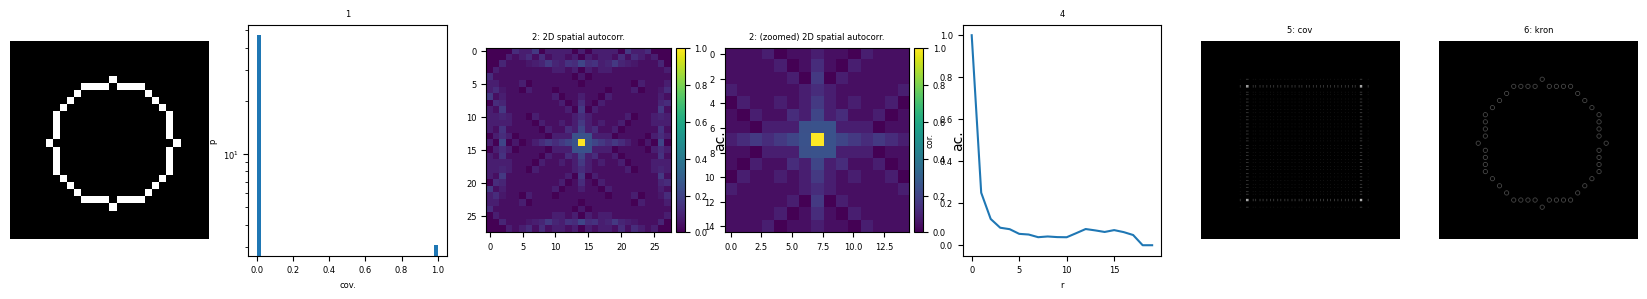

In [198]:
#a = np.zeros((28,28))
#w,h = a.shape[1],a.shape[0]
#color=(255,255,255)
#cv2.circle(a,center=(w//2,h//2), radius=2*min(w, h)//6,color=color, thickness=1)
a = make_glyph(n=15)
xshow_img(a)

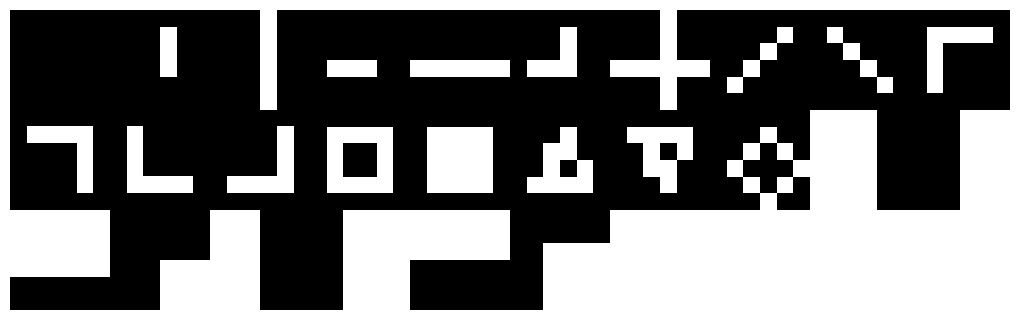

In [55]:

from enum import Enum, auto

class Glyph(Enum):
    FILL = auto()
    VSLINE = auto()
    VLINE = auto()
    HSLINE = auto()
    HLINE = auto()
    PLUS = auto()
    CROSS = auto()
    SLASH = auto()
    BACKSLASH = auto()
    CORNER_TL = auto()
    CORNER_TR = auto()
    CORNER_BL = auto()
    CORNER_BR = auto()
    SQUARE = auto()
    BLOCK = auto()
    TRIANGLE = auto()
    INV_TRIANGLE = auto()
    CIRC = auto()
    LEFT = auto()
    RIGHT = auto() 
    TOP = auto()
    BOTTOM = auto()   
    LEFT3 = auto()
    RIGHT3 = auto() 
    TOP3 = auto()
    BOTTOM3 = auto()   

    def __str__(self):
        return self.name.lower().capitalize()

def glyph(n=0, shape=(28,28), color=(255,255,255), lw=1, dx=0, dy=0, sx=1, sy=1, rot=0, rescale=True):
    return make_glyph(n, shape=shape, color=color, lw=lw, dx=dx, dy=dy, sx=sx, sy=sy, rot=rot, rescale=rescale)
    
def make_glyph(n=0, shape=(28,28), color=(255,255,255), lw=1, dx=0, dy=0, sx=1, sy=1, rot=0, rescale=True):
    a = np.zeros(shape, dtype=np.uint8)
    w,h = a.shape[1],a.shape[0]
    if isinstance(n, int):
        n = list(Glyph)[n]
    if n==Glyph.FILL: 
        cv2.rectangle(a, (0,0), (w,h), color, -1)
    elif n==Glyph.VSLINE:
        cv2.line(a,(w//2,h//4),(w//2,h//4*3),color,lw)
    elif n==Glyph.VLINE:
        cv2.line(a,(w//2,0),(w//2,h),color,lw)
    elif n==Glyph.HSLINE:
        cv2.line(a,(w//4,h//2),(w//4*3,h//2),color,lw)
    elif n==Glyph.HLINE:
        cv2.line(a,(0,h//2),(w,h//2),color,lw)
    elif n==Glyph.PLUS:
        cv2.line(a,(w//2,h//4),(w//2,h//4*3),color,lw)
        cv2.line(a,(w//4,h//2),(w//4*3,h//2),color,lw)
    elif n==Glyph.CROSS:
        cv2.line(a,(w//2,0),(w//2,h),color,lw)
        cv2.line(a,(0,h//2),(w,h//2),color,lw)
    elif n==Glyph.SLASH:
        cv2.line(a,(3*w//4,h//4),(w//4,3*h//4),color,lw)
    elif n==Glyph.BACKSLASH: #GLYPH_
        cv2.line(a,(w//4,h//4),(3*w//4,3*h//4),color,lw)
    elif n==Glyph.CORNER_TL: #GLYPH_
        cv2.line(a,(w//4,h//4),(3*w//4,h//4),color,lw)
        cv2.line(a,(w//4,h//4),(w//4,3*h//4),color,lw)
    elif n==Glyph.CORNER_TR: 
        cv2.line(a,(w//4,h//4),(3*w//4,h//4),color,lw)
        cv2.line(a,(3*w//4,h//4),(3*w//4,3*h//4),color,lw)
    elif n==Glyph.CORNER_BL:
        cv2.line(a,(w//4,3*h//4),(3*w//4,3*h//4),color,lw)
        cv2.line(a,(w//4,h//4),(w//4,3*h//4),color,lw)
    elif n==Glyph.CORNER_BR:
        cv2.line(a,(w//4,3*h//4),(3*w//4,3*h//4),color,lw)
        cv2.line(a,(3*w//4,h//4),(3*w//4,3*h//4),color,lw)
    elif n==Glyph.SQUARE: 
        cv2.line(a,(w//4,h//4),(3*w//4,h//4),color,lw)
        cv2.line(a,(w//4,3*h//4),(3*w//4,3*h//4),color,lw)
        cv2.line(a,(w//4,h//4),(w//4,3*h//4),color,lw)
        cv2.line(a,(3*w//4,h//4),(3*w//4,3*h//4),color,lw)
    elif n==Glyph.BLOCK:
        cv2.rectangle(a, (w//4,h//4), (3*w//4,3*h//4), color=color, thickness=-1)
    elif n==Glyph.TRIANGLE:
        cv2.line(a,(w//4,3*h//4),(3*w//4,3*h//4),color,lw)
        cv2.line(a,(w//4,3*h//4),(w//2,h//4),color,lw)
        cv2.line(a,(3*w//4,3*h//4),(w//2,h//4),color,lw)
    elif n==Glyph.INV_TRIANGLE:
        cv2.line(a,(w//4,h//4),(3*w//4,h//4),color,lw)
        cv2.line(a,(w//4,h//4),(w//2,3*h//4),color,lw)
        cv2.line(a,(3*w//4,h//4),(w//2,3*h//4),color,lw)
    elif n==Glyph.CIRC:
        cv2.circle(a,(w//2,h//2), 2*min(w, h)//6, color, lw)
    elif n==Glyph.LEFT:        
        cv2.rectangle(a, (0, 0), (w//2,h), color, -1)
    elif n==Glyph.RIGHT:        
        cv2.rectangle(a, (w//2,0), (w,h), color, -1)
    elif n==Glyph.TOP:        
        cv2.rectangle(a, (0, 0), (w,h//2), color, -1)
    elif n==Glyph.BOTTOM:        
        cv2.rectangle(a, (w//2, h//2), (w,h), color, -1)
    elif n==Glyph.LEFT3:        
        cv2.rectangle(a, (0, 0), (w//3,h), color, -1)
    elif n==Glyph.RIGHT3:        
        cv2.rectangle(a, (w//3,0), (w,h), color, -1)
    elif n==Glyph.TOP3:        
        cv2.rectangle(a, (0, 0), (w,h//3), color, -1)
    elif n==Glyph.BOTTOM3:        
        cv2.rectangle(a, (w//3, h//3), (w,h), color, -1)
        
    if dx!=0 or dy!=0:
        dxy = np.float32([[1, 0, dx], [0, 1, dy]])
        a = cv2.warpAffine(a, dxy, (w, h))
    if sx!=1 or sy!=1:
        a = cv2.resize(a, None, fx=sx, fy=sy, interpolation=cv2.INTER_AREA) #| cv2.INTER_CUBIC | INTER_LINEAR
    if rot!=0:
        rm = cv2.getRotationMatrix2D((w//2,h//2), rot, 1.0)
        a = cv2.warpAffine(a, rm, (w, h))
    if rescale:
       a = a.astype(float)/255
    return a

def make_glyphs(nn=None, shape=(28,28), color=(255,255,255), lw=1, dx=0, dy=0, sx=1, sy=1, rot=0, rescale=True):
    if nn is None:
        nn = list(Glyph)
    return [ make_glyph(n, shape=shape, color=color, lw=lw, dx=dx, dy=dy, sx=sx, sy=sy, rot=rot, rescale=rescale) for n in nn ] 


def show_glyphs(nn=None, shape=(28,28), color=(255,255,255), lw=1, dx=0, dy=0, sx=1, sy=1, rot=0, rescale=True, ncols=10, pad=1):
    if nn is None:
        nn = list(Glyph)
    ncols = min(ncols, len(nn))
    nrows = len(nn) // ncols + int(len(nn)%ncols!=0)
    if len(nn)>0 and not isinstance(nn[0], np.ndarray):
        aa = make_glyphs(nn, shape=shape, color=color, lw=lw, dx=dx, dy=dy, sx=sx, sy=sy, rot=rot, rescale=rescale)
        titles = [ str(g) for g in nn ]
    else:
        aa = nn
        titles = None
    show_imgs(aa, ncols=10, titles=titles, title_size=6, figsize=(ncols*1, nrows*1))

    
aa = make_glyphs(shape=(6,6))
aa = [a/ a.sum()*a.size for a in aa ]
show_glyphs(aa)




(5, 5)
[[0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 1. 0. 1. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]
[[0.    0.    0.    0.    0.   ]
 [0.    0.125 0.125 0.125 0.   ]
 [0.    0.125 0.    0.125 0.   ]
 [0.    0.125 0.125 0.125 0.   ]
 [0.    0.    0.    0.    0.   ]]
[[0.     0.     0.     0.     0.    ]
 [0.     0.3536 0.3536 0.3536 0.    ]
 [0.     0.3536 0.     0.3536 0.    ]
 [0.     0.3536 0.3536 0.3536 0.    ]
 [0.     0.     0.     0.     0.    ]]


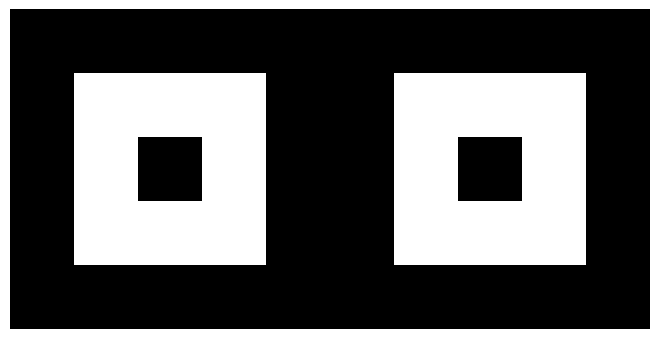

[[[0. 0. 0. 0. 0.]
  [0. 1. 1. 1. 0.]
  [0. 1. 0. 1. 0.]
  [0. 1. 1. 1. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0.]
  [0. 1. 0. 1. 0.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0.]]]
[8. 4.]
[[[0.    0.    0.    0.    0.   ]
  [0.    0.125 0.125 0.125 0.   ]
  [0.    0.125 0.    0.125 0.   ]
  [0.    0.125 0.125 0.125 0.   ]
  [0.    0.    0.    0.    0.   ]]

 [[0.    0.    0.    0.    0.   ]
  [0.    0.    0.25  0.    0.   ]
  [0.    0.25  0.    0.25  0.   ]
  [0.    0.    0.25  0.    0.   ]
  [0.    0.    0.    0.    0.   ]]]


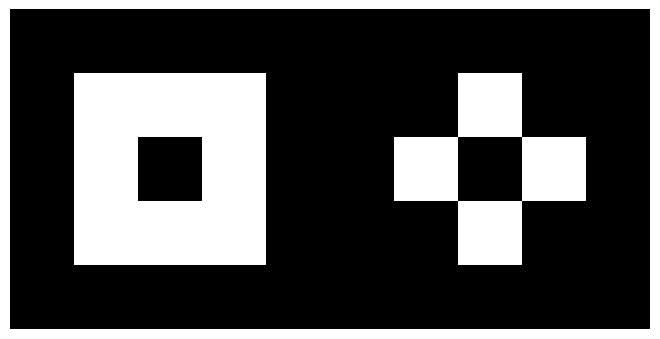

--
[[[0.     0.     0.     0.     0.    ]
  [0.     0.3536 0.3536 0.3536 0.    ]
  [0.     0.3536 0.     0.3536 0.    ]
  [0.     0.3536 0.3536 0.3536 0.    ]
  [0.     0.     0.     0.     0.    ]]

 [[0.     0.     0.     0.     0.    ]
  [0.     0.     0.5    0.     0.    ]
  [0.     0.5    0.     0.5    0.    ]
  [0.     0.     0.5    0.     0.    ]
  [0.     0.     0.     0.     0.    ]]]
[2.8284 2.    ]


In [65]:
def normalize(a, norm=1):
    if norm==1:
        n = np.abs(a).sum()
    elif norm==2:
        n = la.norm(a, axis=(-2,-1))
    else:
        n = 0

    return a/n if n!=0 else a

from numpy import linalg as la

def normalize_all(a, norm=1):
    if norm==1:
        a_ = a.reshape(a.shape[0], -1)
        s_ = np.abs(a_).sum(-1)
        print(s_)
        s_[s_ == 0] = 1
        a_ = a_/s_[:,None]
        return a_.reshape(a.shape)
    elif norm==2:
        n = la.norm(a, axis=(-2,-1))
        a = a / n[:,None,None]
        return a
    else:
        return a        
    
a = glyph(Glyph.SQUARE, shape=(5,5), rescale=True)
#a = np.zeros((5,5), dtype=np.uint8)
#w,h = a.shape[1],a.shape[0]
#cv2.rectangle(a, (w//4,h//4), (3*w//4,3*h//4), color=color, thickness=-1)

print(a.shape)
print(a)
a_ = normalize(a)
print(a_)
a_ = normalize(a, 2)
print(a_)

show_imgs([a, a_], ncols=2)

aa = make_glyphs([Glyph.SQUARE, Glyph.CIRC], shape=(5,5))
aa_ = np.array(aa)
print(aa_)
aa1 = normalize_all(aa_, 1)
print(aa1)
show_imgs(aa1, ncols=2)
print('--')
aa2 = normalize_all(aa_, 2)
print(aa2)
print(la.norm(aa_, axis=(-2,-1)))


(26, 8, 8)


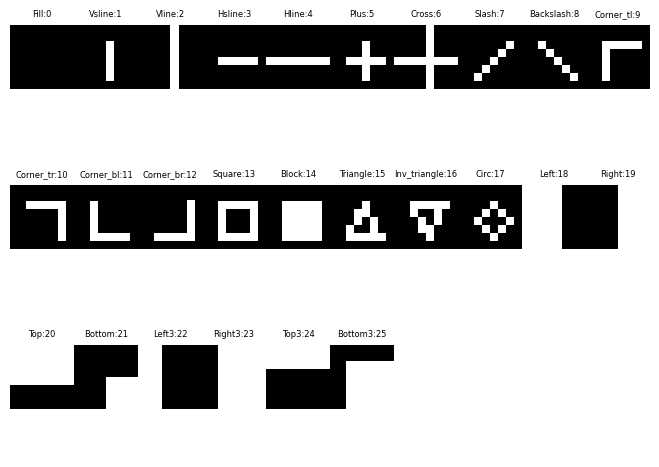

In [282]:
def glyph_dataset(n, gg=None, shape=(28,28), color=(255,255,255), lw_min=1, lw_max=3, 
            txs=True, unique=False, shuffle=True,
            dx_min=-.2, dx_max=.2, dy_min=-.2, dy_max=.2, sx_min=.8, sx_max=1.2, sy_min=.8, sy_max=1.2, 
            rot_min=-10, rot_max=10, rescale=True):
    if gg is None:
        gg = list(Glyph)
    xx = []
    yy = []
    dd = []
    gg_ = set()
    if not txs:
        n = min(n,len(gg))
    y = 0
    while len(xx)<n:
        if shuffle:
            y = random.randrange(0, len(gg))
            if unique:
                if y in gg_:
                    if len(gg_)==len(gg):
                        break
                    continue
                gg_.add(y)
            g = gg[y]
        else:
            g = gg[y]
        if txs:
            lw_min = max(min(1, int(min(shape[0],shape[1])*lw_min)), a.shape[0]//4) if isinstance(lw_min, float) else lw_min
            lw_max = max(min(1, int(min(shape[0],shape[1])*lw_max)), a.shape[0]//4) if isinstance(lw_max, float) else lw_max
            lw = random.randrange(lw_min, lw_max)
            dx_min = int(shape[1]*dx_min) if isinstance(dx_min, float) else dx_min
            dx_max = int(shape[1]*dx_max) if isinstance(dx_max, float) else dx_max
            dy_min = int(shape[1]*dy_min) if isinstance(dy_min, float) else dy_min
            dy_max = int(shape[1]*dy_max) if isinstance(dy_max, float) else dy_max
            dx = random.randrange(dx_min, dx_max)
            dy = random.randrange(dy_min, dy_max)
            sx = sx_min + random.random()* (sx_max-sx_min)
            sy = sx_min + random.random()* (sy_max-sy_min)
            rot = rot_min + random.random() * (rot_max-rot_min)        
        else:
            lw = 1
            dx = dy = 0
            sx = sy = 1
            rot = 0
        a = make_glyph(g, shape=shape, color=color, lw=lw, dx=dx, dy=dy, sx=sx, sy=sy, rot=rot, rescale=rescale)
        xx.append(a)
        yy.append(y)
        dd.append({'label': y, 'id': g, 'color': color, 'lw': lw, 'dx':dx, 'dy':dy, 'sx':sx, 'sy': sy, 'rot': rot})
        if not shuffle:
            y += 1
            y %= len(gg)

    xx = np.array(xx)
    yy = np.array(yy)
    return xx, yy, gg, dd

ds = xx, yy, labels, dd = glyph_dataset(len(Glyph), shape=(8,8), shuffle=False, txs=False)
print(xx.shape)
_=show_imgs(xx, ncols=10, title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])


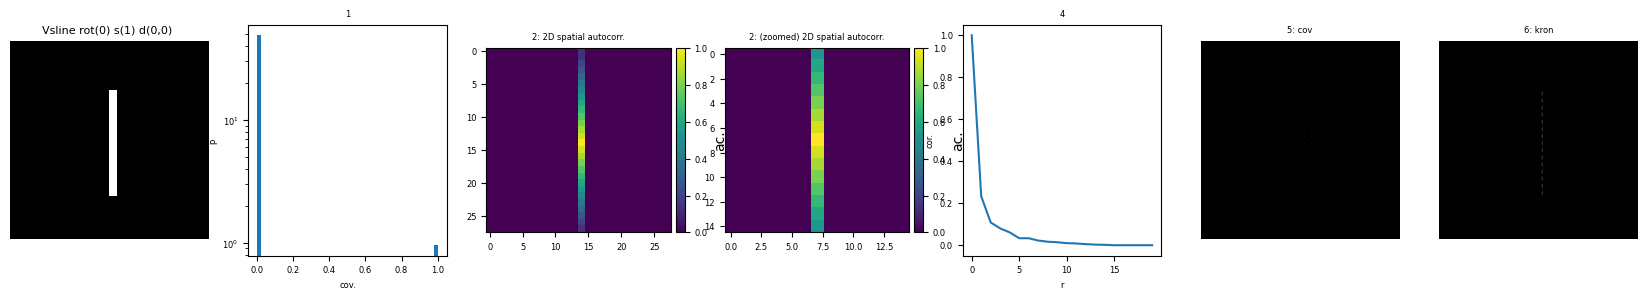

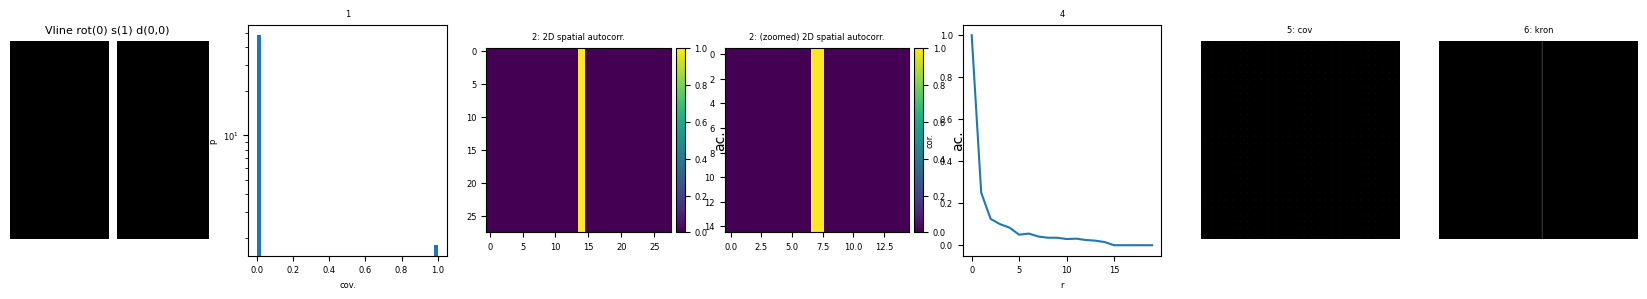

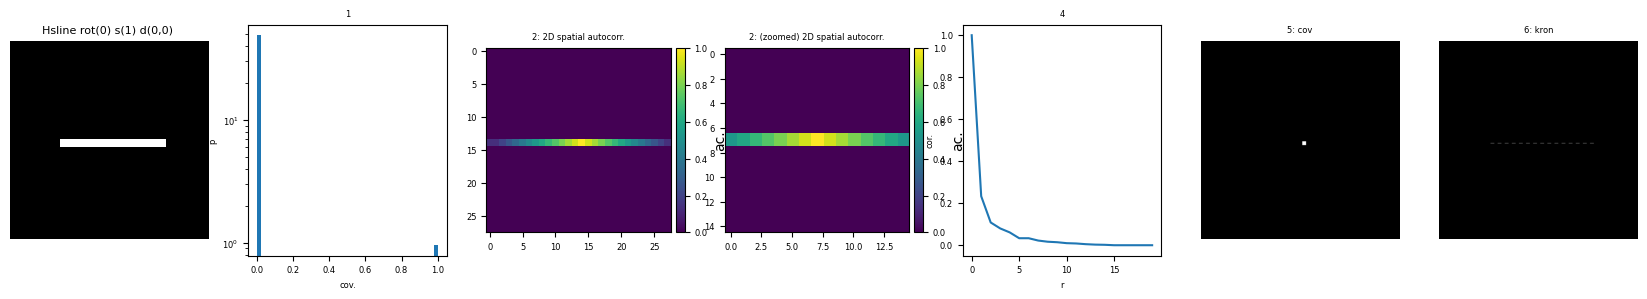

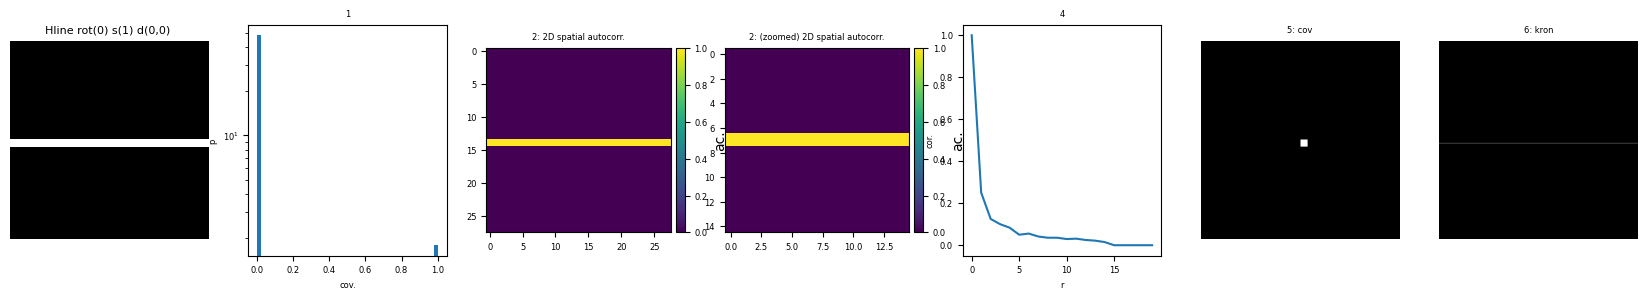

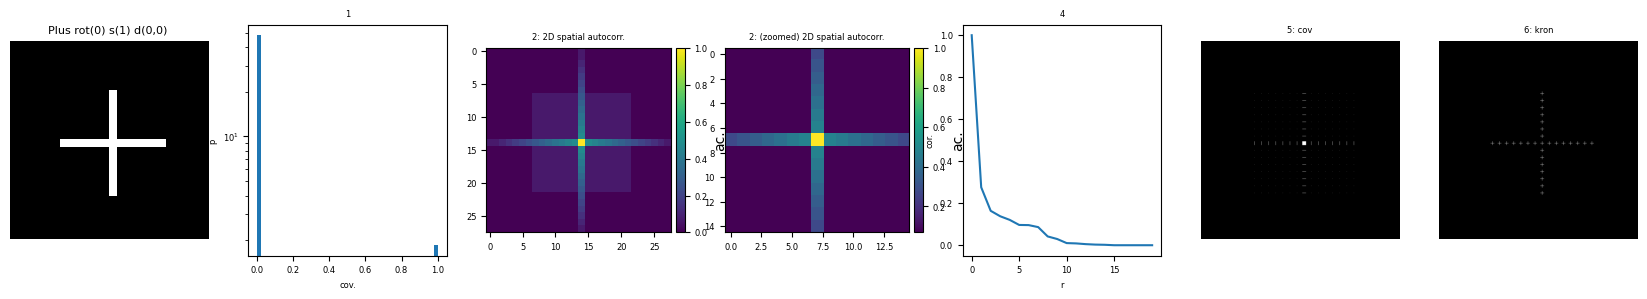

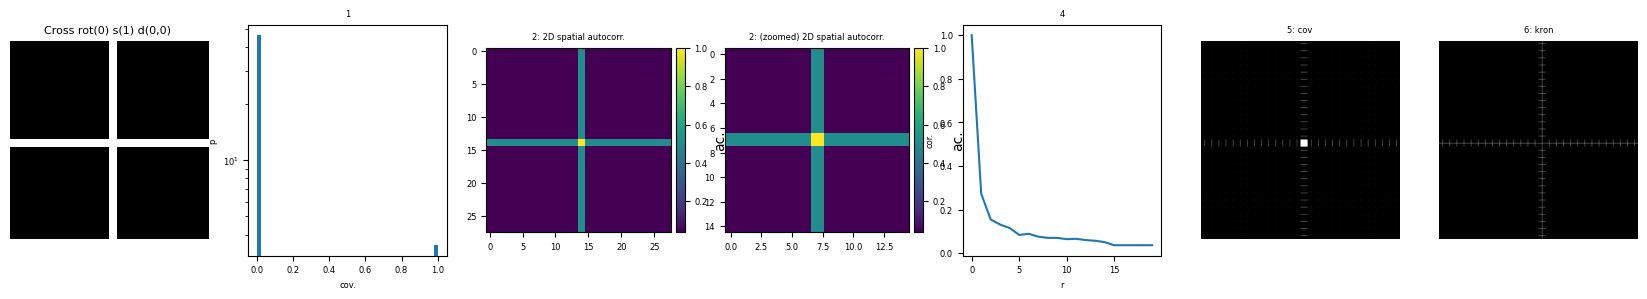

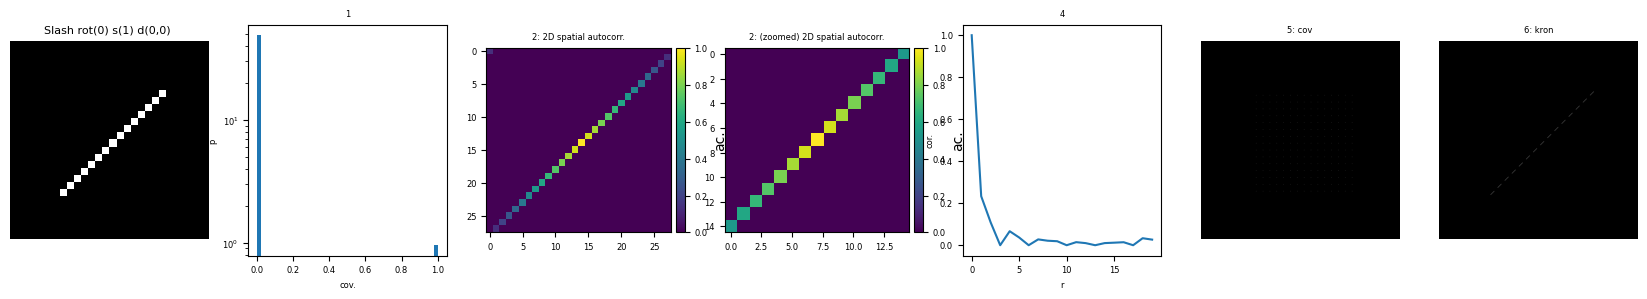

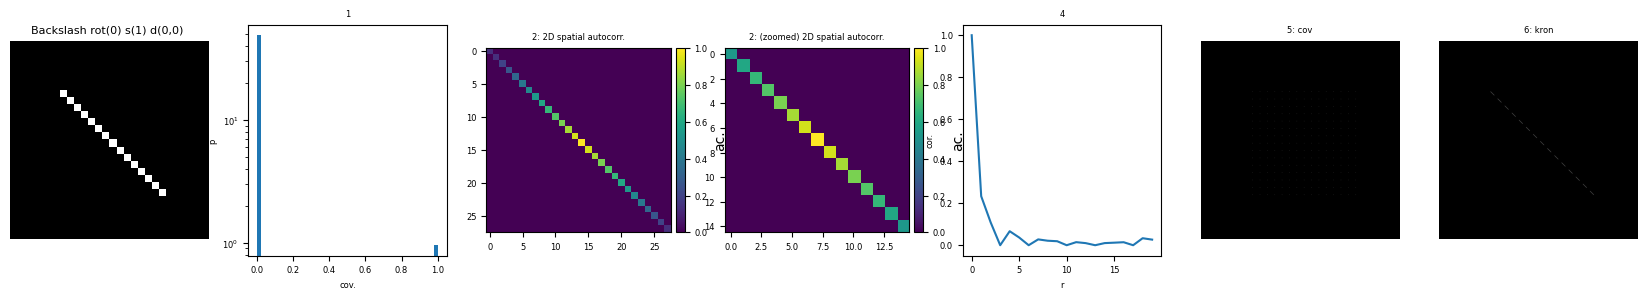

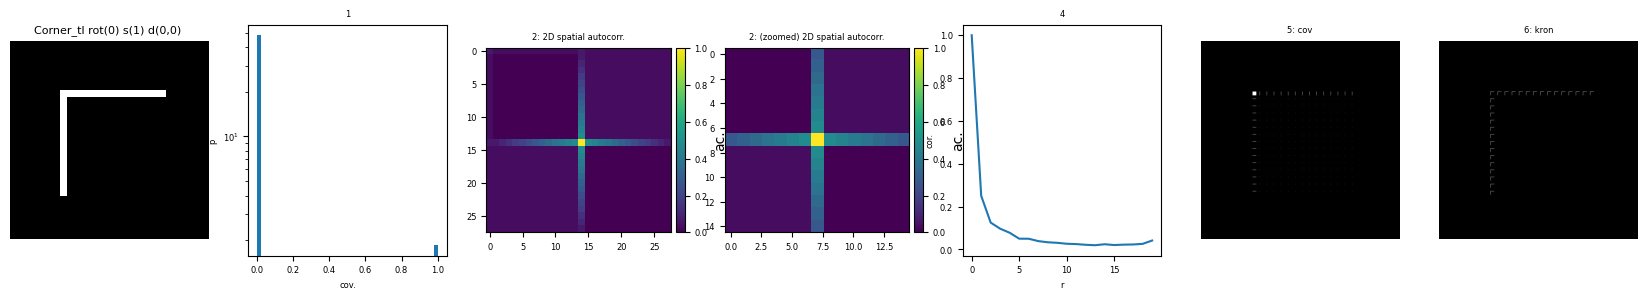

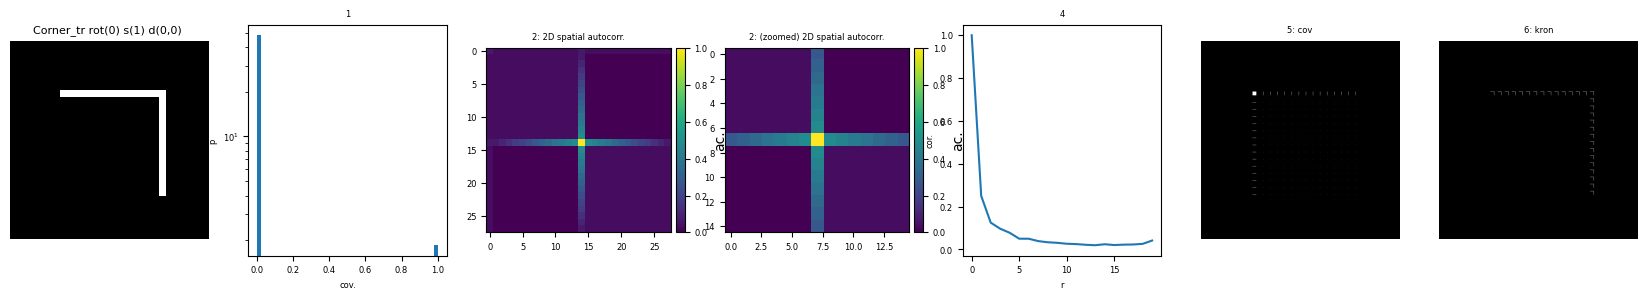

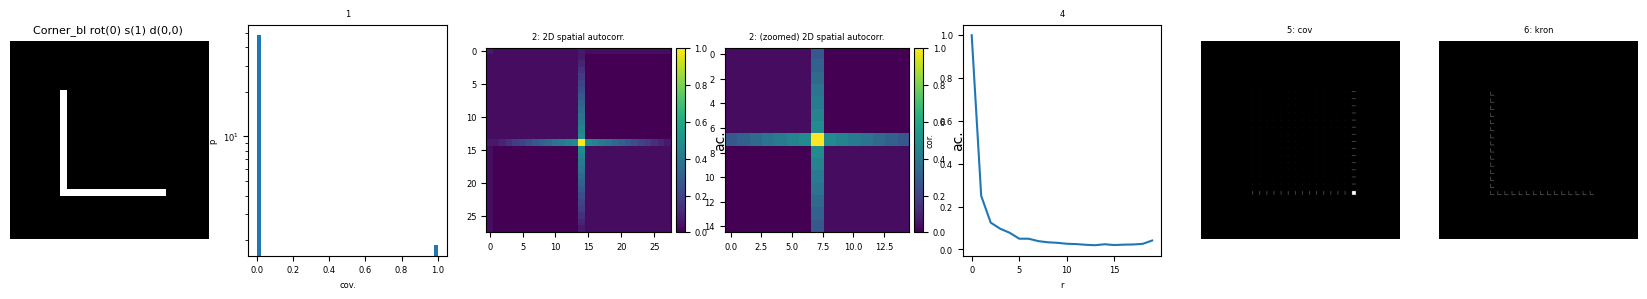

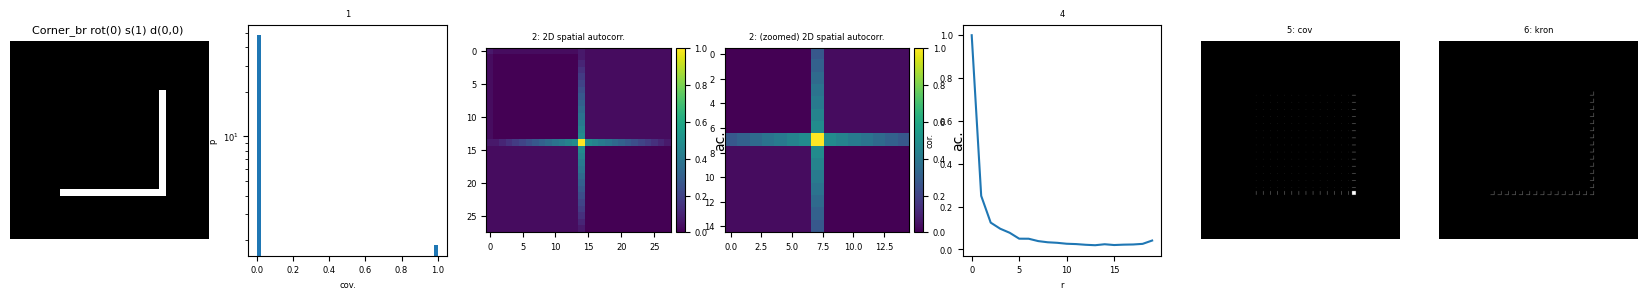

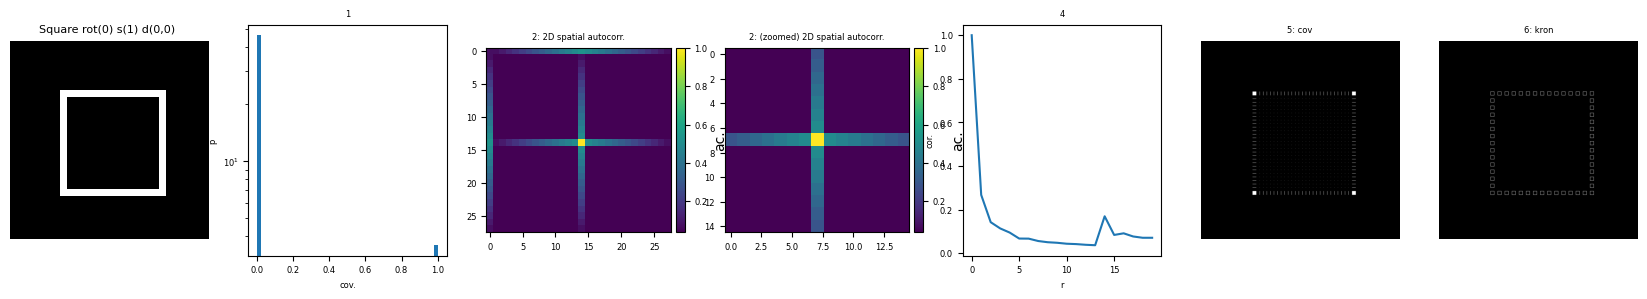

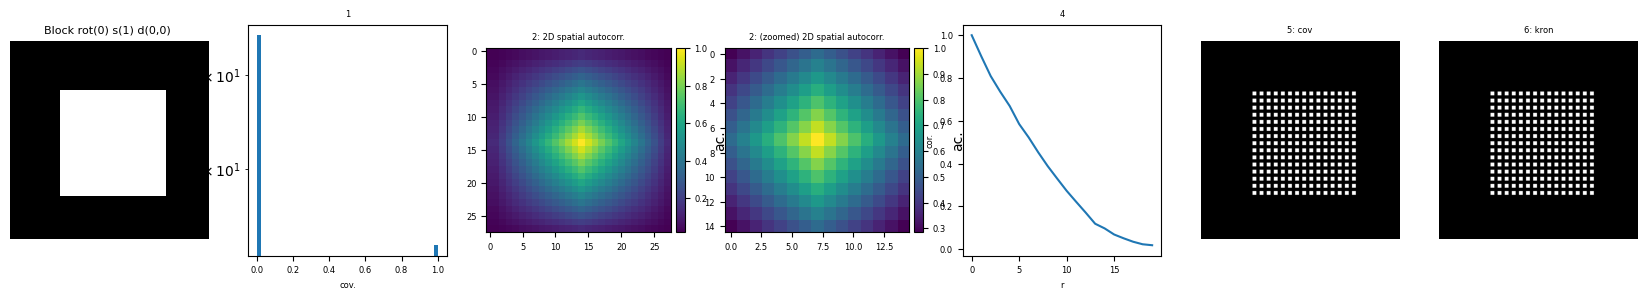

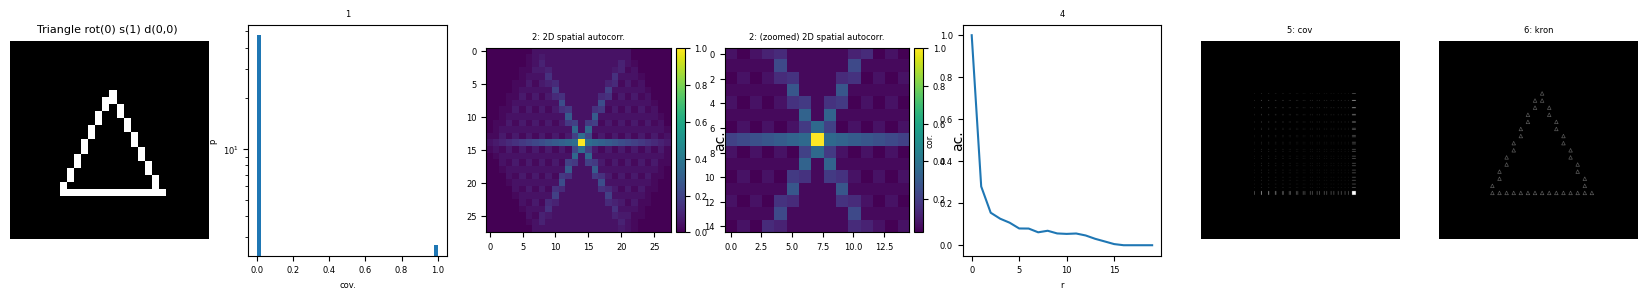

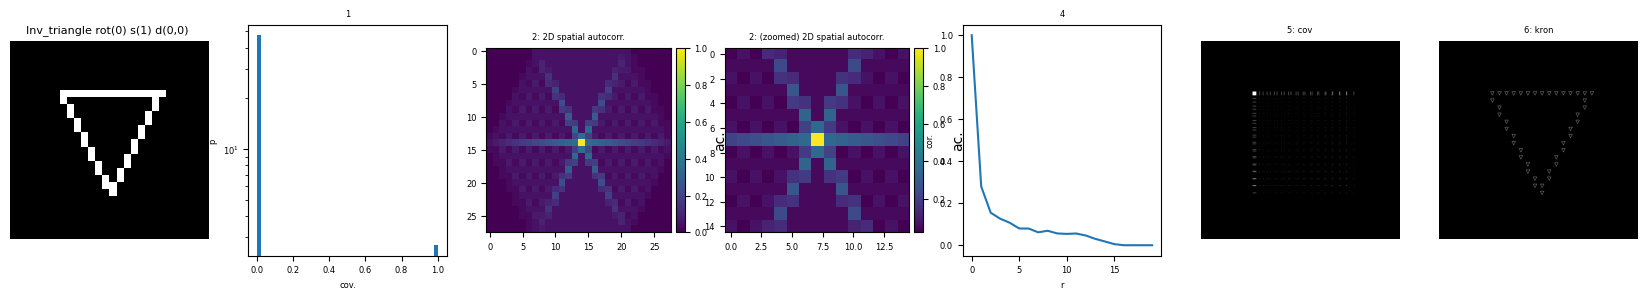

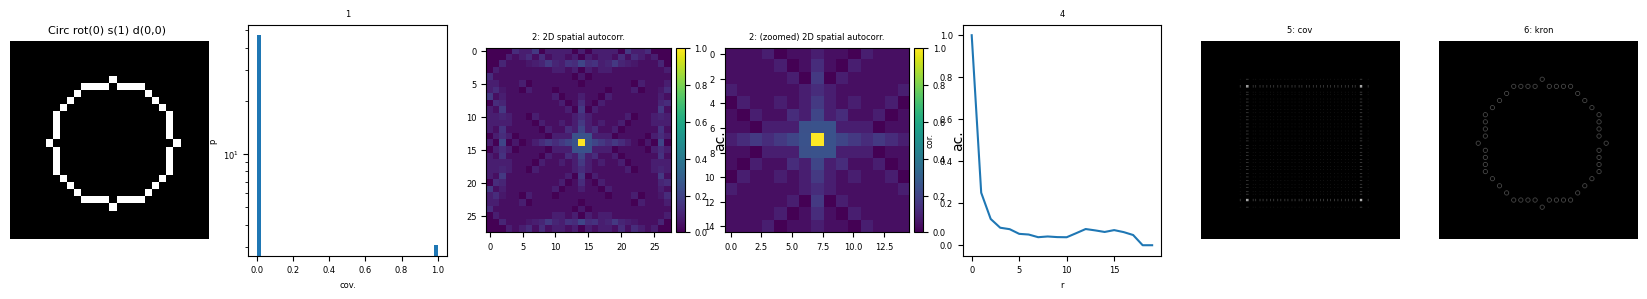

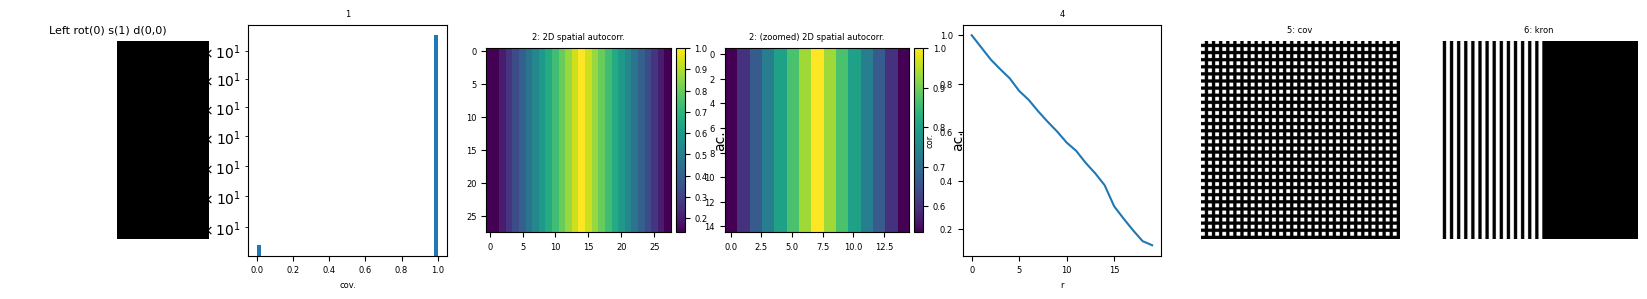

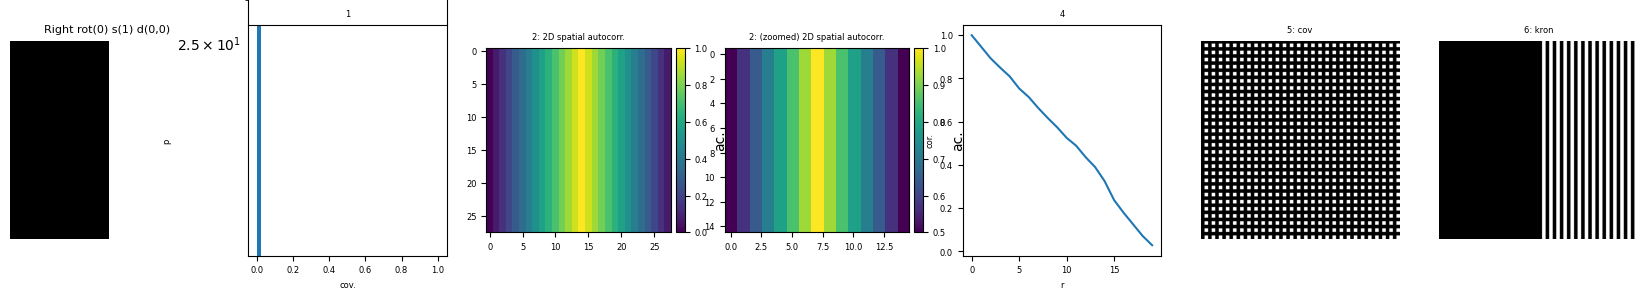

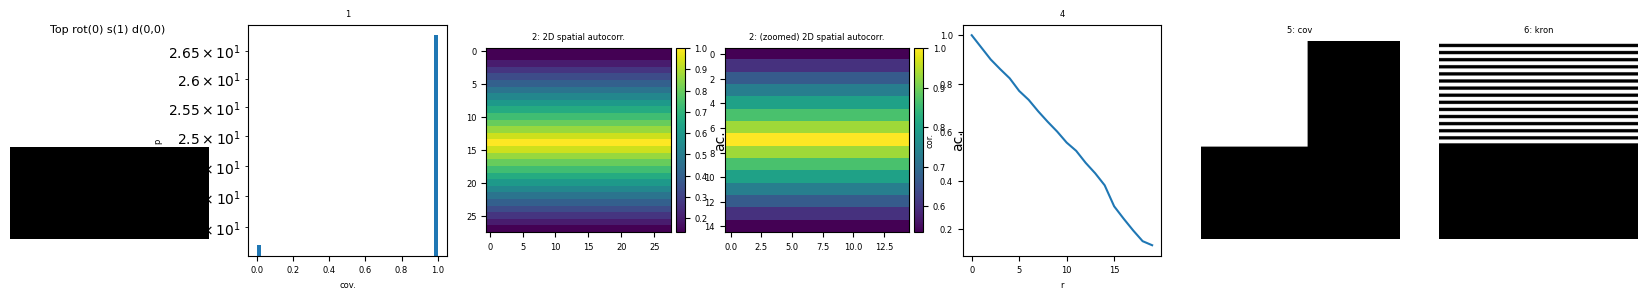

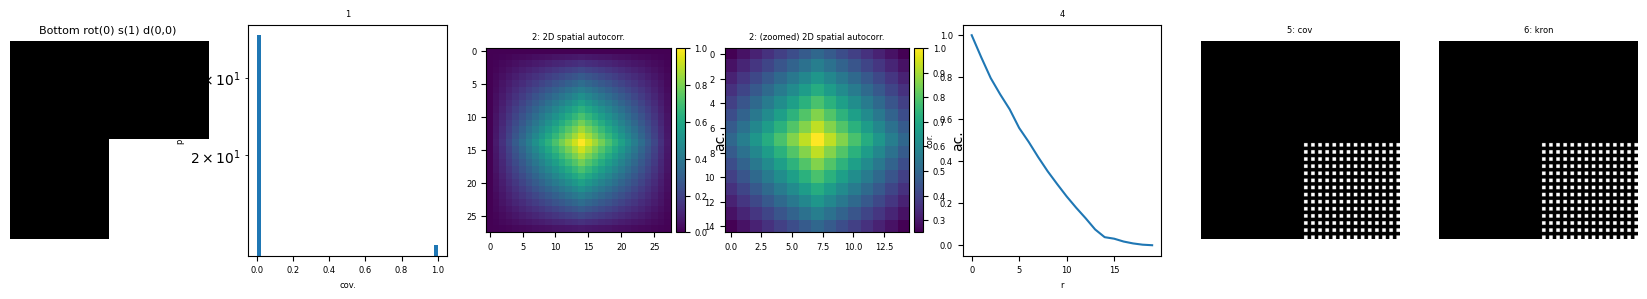

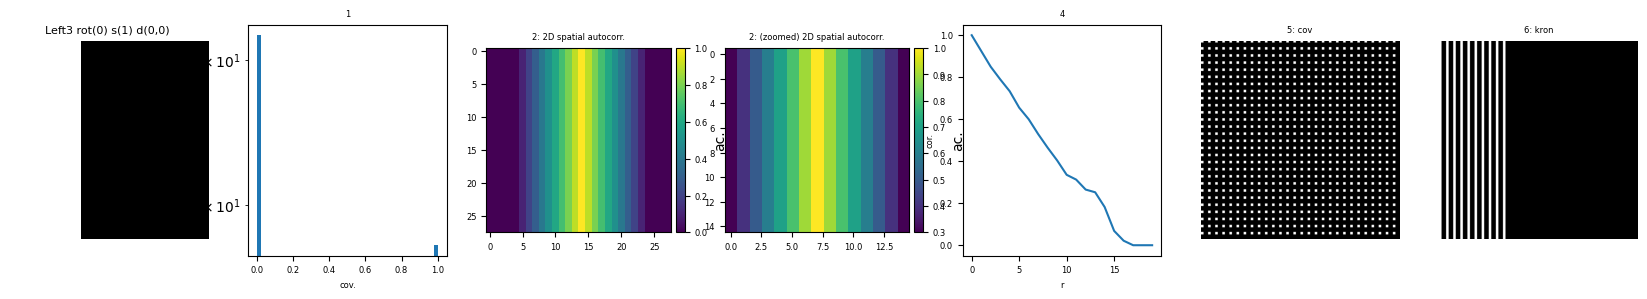

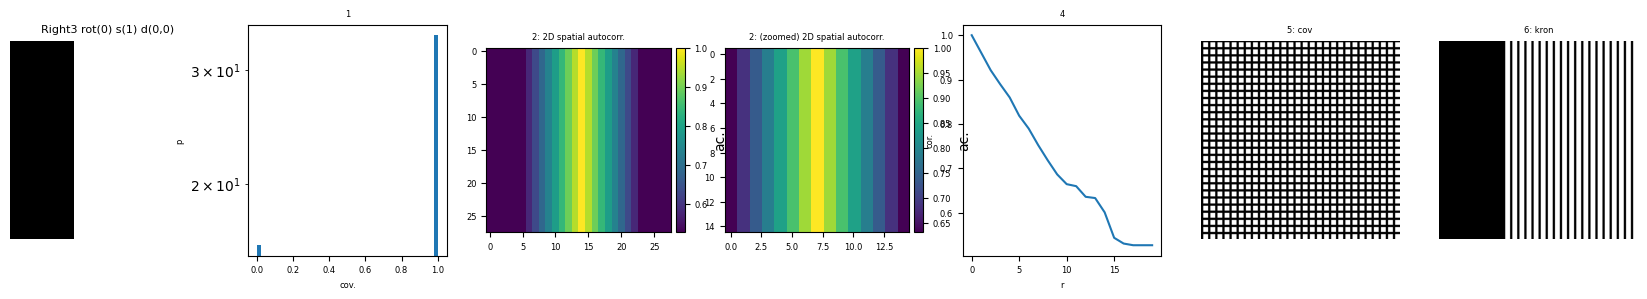

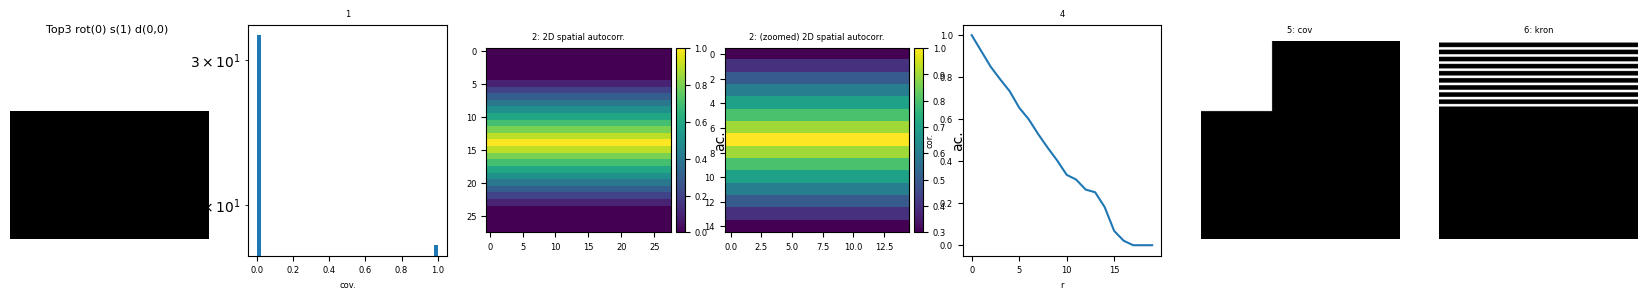

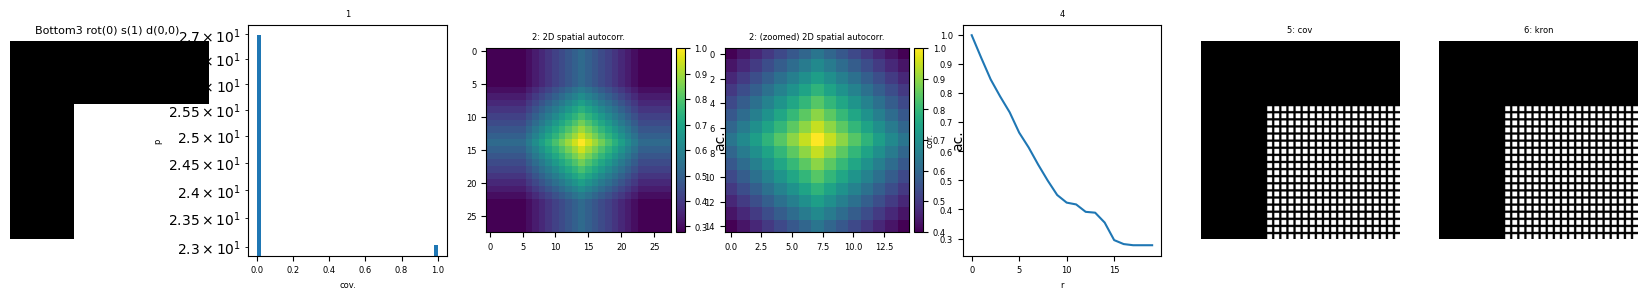

In [ ]:
def show_glyph_txs(i, rot=True, sxy=True, dx=True, dy=True,
                   imshow =True, cov_histo=True, ac2d=True, acr=True, cov=True, kron=True):
    def _values(x, value0, value1):
        if isinstance(x, list):
            return x
        if isinstance(x, bool):
            return value1 if x else value0
        return [x]
    rot = _values(rot, [0], [0, -20, +20])
    sxy = _values(sxy, [1], [1, 1.5])
    dx = _values(dx, [0], [0, 10])
    dy = _values(dy, [0], [0, 10])
    for rot_ in rot:
        for sxy_ in sxy:
            for dx_ in dx:
                for dy_ in dy:
                    a = make_glyph(i, dx=dx_, dy=dy_, sx= sxy_, sy=sxy_, rot=rot_)
                    xshow_img(a, title=f'{i} rot({rot_}) s({sxy_}) d({dx_},{dy_}) ', title_size=8,
                    imshow=imshow, cov_histo=cov_histo, ac2d=ac2d, acr=acr, cov=cov, kron=kron)

for g in Glyph:
    show_glyph_txs(g, rot=False, sxy=False, dx=False, dy=False)
    


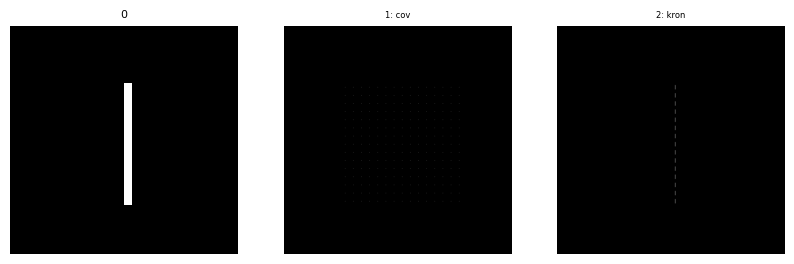

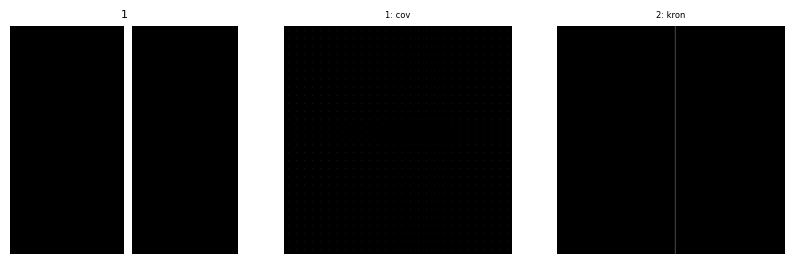

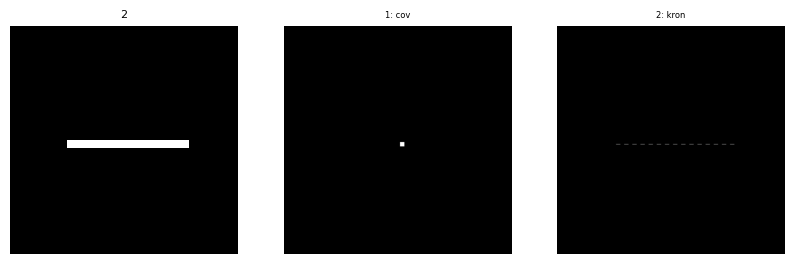

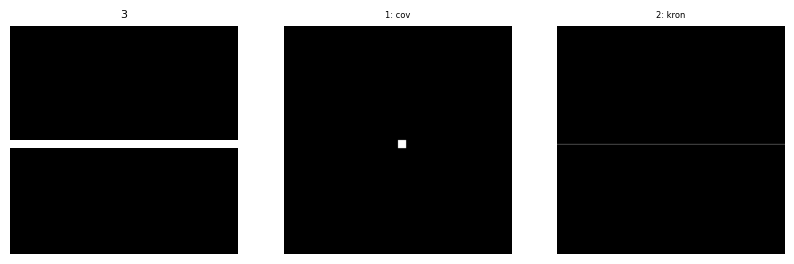

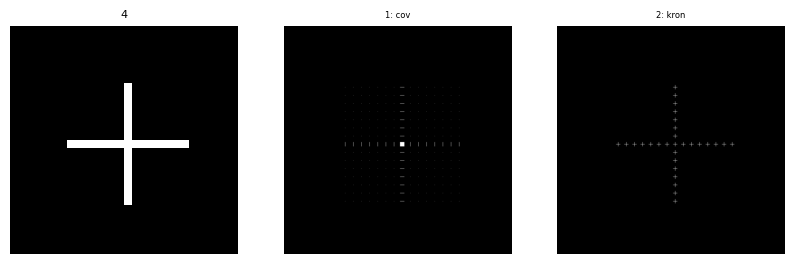

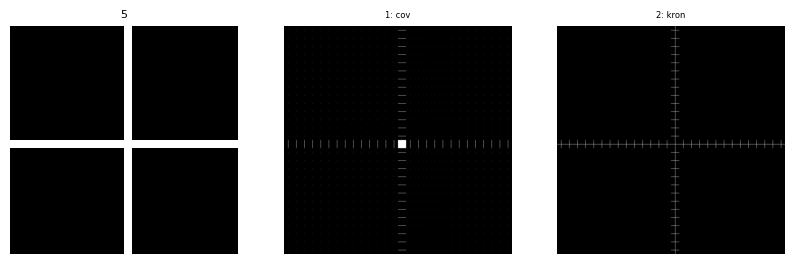

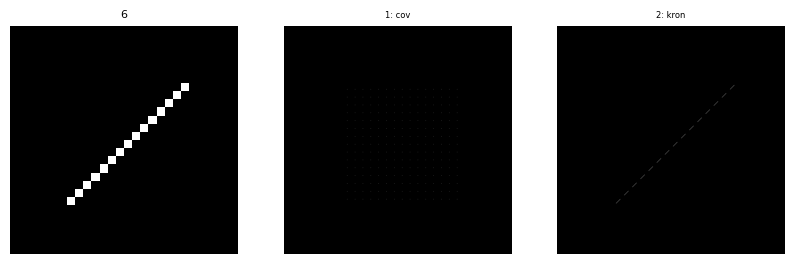

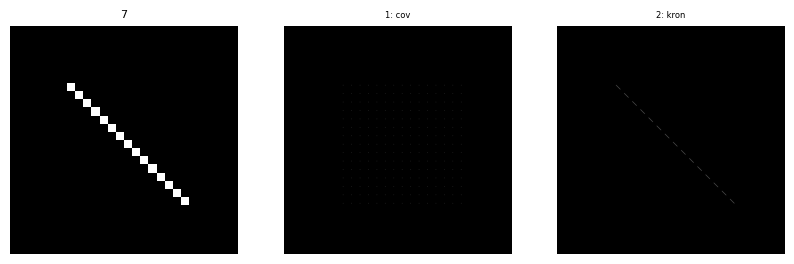

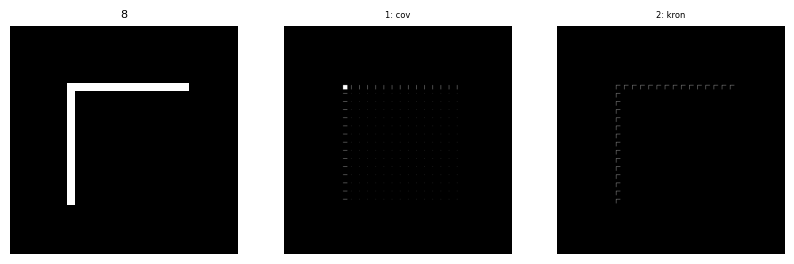

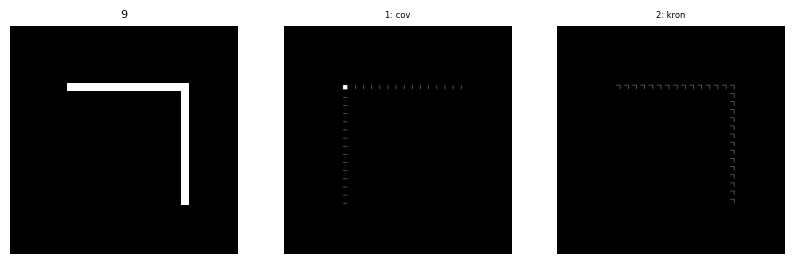

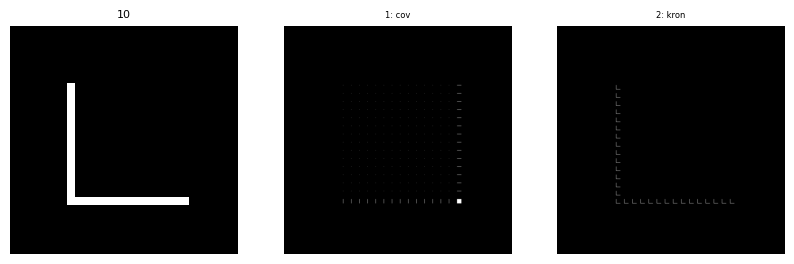

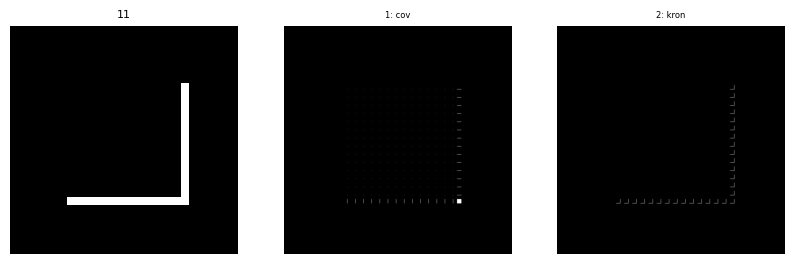

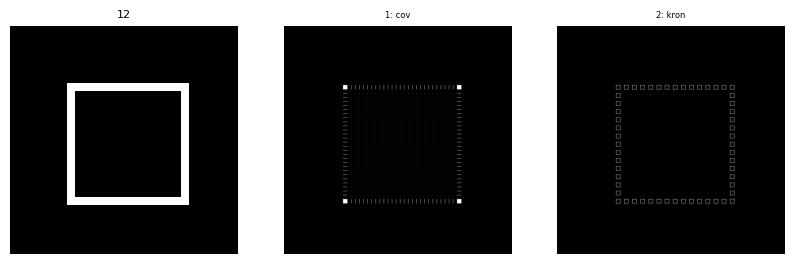

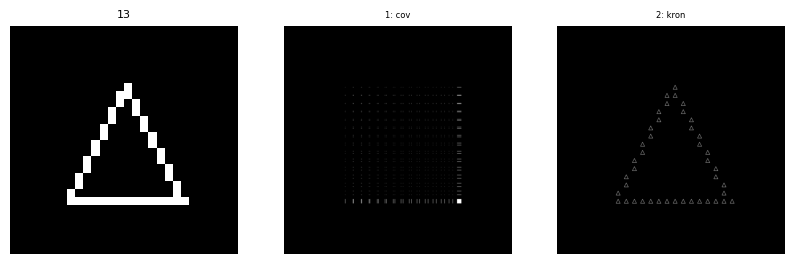

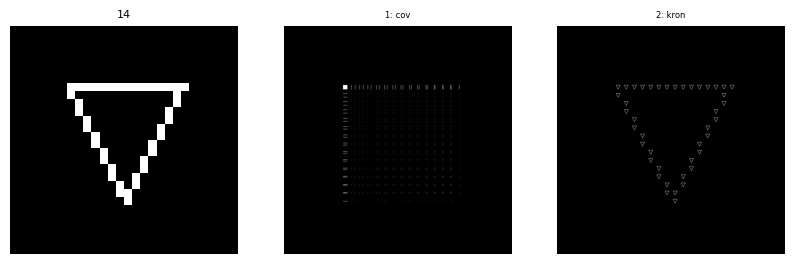

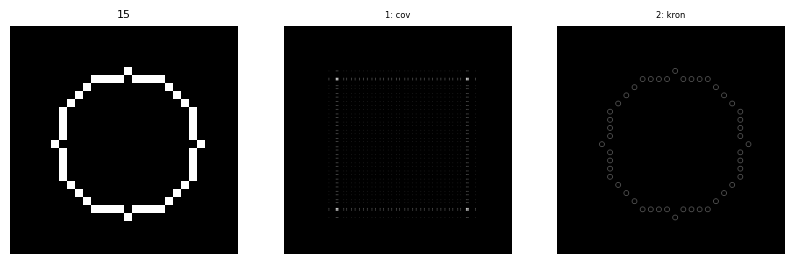

In [ ]:
for i in range(0, 16):
    #show_glyph_txs(i, rot=False, sxy=False, dx=False, dy=False)
    a = make_glyph(i, dx=0, dy=0, sx= 1, sy=1, rot=0)
    #print(A.shape)
    #print(A.sum(), A.max())
    #A = img_cov(a)
    #compute_show_img_cov(a)
    xshow_img(a, title=f'{i}', figsize=(5*2, 5),
        imshow=True, cov_histo=False, ac2d=False, acr=False, cov=True, kron=True)

#print(A_.nonzero())
#print(A_[210])
#self.Zp = np.outer(zy, zs)
#self.Zn = np.outer(zy, 1-zs)

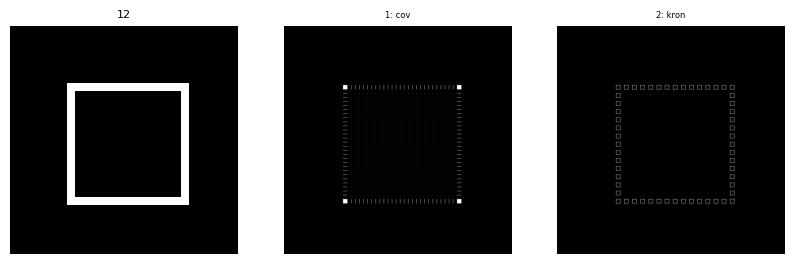

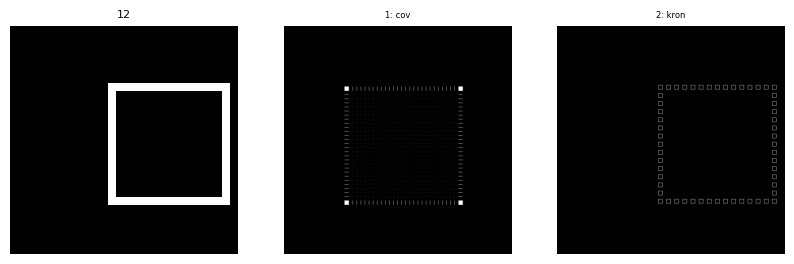

(28, 28)
a: (28, 28) C: (784, 784) Kron: (784, 784)


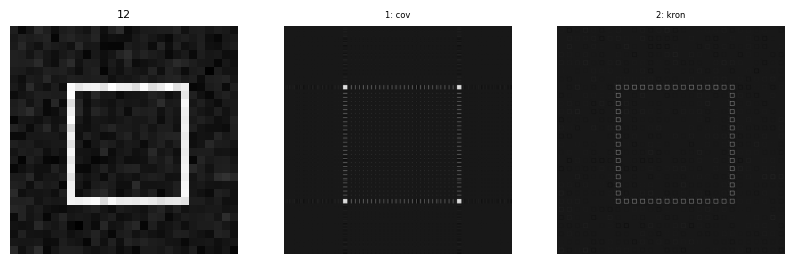

In [183]:
s = 12
a = make_glyph(s, dx=0, dy=0, sx= 1, sy=1, rot=0)
a1 = make_glyph(s, dx=5, dy=0, sx= 1, sy=1, rot=0)
xshow_img(a, title=f'{s}', figsize=(5*2, 5), imshow=True, cov_histo=False, ac2d=False, acr=False, cov=True, kron=True)
xshow_img(a1, title=f'{s}', figsize=(5*2, 5), imshow=True, cov_histo=False, ac2d=False, acr=False, cov=True, kron=True)

print(a.shape)
C = img_cov(a)
kaa = np.kron(a, a)
print('a:', a.shape, 'C:', C.shape, 'Kron:', kaa.shape)
r = np.random.normal(0, 10, a.shape)
ra = a + r
xshow_img(ra, title=f'{s}', figsize=(5*2, 5), imshow=True, cov_histo=False, ac2d=False, acr=False, cov=True, kron=True)

#show_img(a)
#show_img(C)
#show_img(kaa)
#show_img(a)



In [283]:
g = Glyph.SQUARE
a = make_glyph(g, shape=(6,6))
a1 = make_glyph(g, shape=a.shape, dx=5)
Ca = img_cov(a)
Ca1 = img_cov(a1)
Ka = np.kron(a, a)
Ka1 = np.kron(a1, a1)
print('a:', a.shape, 'Ca:', Ca.shape, 'Ka:', Ka.shape)
a_ = a.flatten()
print('a:', a.shape, 'a_:', a_.shape, 'M:', M.shape)
print(a)


NameError: name 'img_cov' is not defined

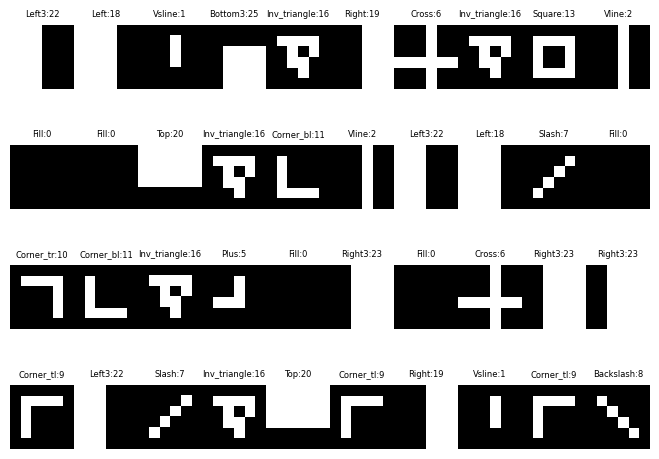

In [7]:
ds = xx, yy, dd = glyph_dataset(40, shape=(6,6), txs=False)
_=show_imgs(xx, ncols=10, title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])


[0 1 2 3]
[<Glyph.SQUARE: 14>, <Glyph.CIRC: 18>, <Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>]


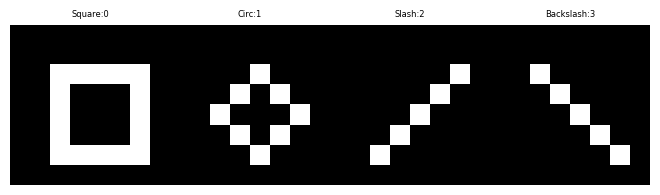

(4, 4)
[[0.25   0.0625 0.0312 0.0312]
 [0.0625 0.125  0.0312 0.0312]
 [0.0312 0.0312 0.0781 0.0156]
 [0.0312 0.0312 0.0156 0.0781]]


,Square,Circ,Slash,Backslash
Square,0.25000,0.06250,0.031250,0.031250
Circ,0.06250,0.12500,0.031250,0.031250
Slash,0.03125,0.03125,0.078125,0.015625
Backslash,0.03125,0.03125,0.015625,0.078125


In [293]:
gg = [Glyph.SQUARE, Glyph.CIRC, Glyph.SLASH, Glyph.BACKSLASH]
#gg = [Glyph.SLASH, Glyph.BACKSLASH]
ds0 = xx, yy, labels, dd = glyph_dataset(len(gg), gg=gg, unique=True, shuffle=False, shape=(8,8), txs=False)
print(yy)
print(labels)

#xx = normalize_all(xx, 2)
_=show_imgs(xx, ncols=min(10, xx.shape[0]), title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])
xx__ = xx.reshape(xx.shape[0], -1)
sim = (xx__ @ xx_.T)/xx_.shape[-1]
print(sim.shape)
print(sim)
df = pd.DataFrame(sim, columns=gg, index=gg)
display(df)

ds: 4
N: 16
M: (16, 64)
t:0/120 3:Slash
t:1/120 1:Square
t:2/120 0:Backslash
t:3/120 3:Slash
t:4/120 2:Circ
t:5/120 1:Square
t:6/120 0:Backslash
t:7/120 2:Circ
t:8/120 2:Circ
t:9/120 3:Slash
t:10/120 0:Backslash
t:11/120 2:Circ
t:12/120 2:Circ
t:13/120 0:Backslash
t:14/120 2:Circ
t:15/120 2:Circ
t:16/120 2:Circ
t:17/120 3:Slash
t:18/120 3:Slash
t:19/120 2:Circ
t:20/120 3:Slash
t:21/120 2:Circ
t:22/120 1:Square
t:23/120 3:Slash
t:24/120 2:Circ
t:25/120 1:Square
t:26/120 0:Backslash
t:27/120 1:Square
t:28/120 3:Slash
t:29/120 0:Backslash
t:30/120 1:Square
t:31/120 0:Backslash
t:32/120 0:Backslash
t:33/120 1:Square
t:34/120 0:Backslash
t:35/120 1:Square
t:36/120 0:Backslash
t:37/120 3:Slash
t:38/120 1:Square
t:39/120 3:Slash
t:40/120 3:Slash
t:41/120 3:Slash
t:42/120 2:Circ
t:43/120 1:Square
t:44/120 2:Circ
t:45/120 3:Slash
t:46/120 3:Slash
t:47/120 3:Slash
t:48/120 0:Backslash
t:49/120 0:Backslash
t:50/120 3:Slash
t:51/120 1:Square
t:52/120 3:Slash
t:53/120 2:Circ
t:54/120 2:Circ
t:55/12

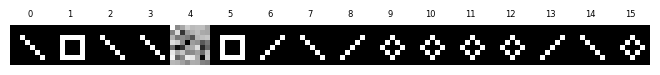

In [253]:
N = (yy.max()+1)*4
w0 = .001
#M = w0*np.ones((N, a.size))
sd = .001
M = np.random.normal(0, sd, (N, xx[0].size))
print('ds:', xx.shape[0])
print('N:', N)
print('M:', M.shape)
#print('M:', M)
#_y = M @ a_
#y = np.clip(_y.flatten(), 0, 1)
#zy = y
#print('y:', y.shape)


xx_ = normalize_all(xx, 2)*3

twp = 5
twn = 5
M__ = []
T= xx.shape[0]*30
#shape = xx[0].shape[0]
#size = xx[0].size
for t in range(0,T):    
    i = random.randrange(xx.shape[0])
    x,lb,d=xx_[i],yy[i],dd[i]
    s = x
    s_ = s.flatten()
    p = .5
    zs = (s_ > p).astype(np.int8)
    #print(zs.reshape(a.shape))
    _y = M @ zs
    y = np.clip(_y.flatten(), 0, 1)
    zy = y
    print(f't:{t}/{T}', f"{lb}:{d['id']}")
    #print('t:', t, 'zs:', zs, '_y:', _y, 'y:', y)
    Zp = np.outer(zy, zs)
    Zn = np.outer(zy, 1-zs)
    M += (1/twp)*Zp - (1/twn)*Zn
    #Zp_ = Zp.reshape(-1, s.shape[0], s.shape[1])
    #Zn_ = Zn.reshape(-1, s.shape[0], s.shape[1])
    M_ = M.copy().reshape(-1, s.shape[0], s.shape[1])
    #print(M_[0])
    M__.append(M_)
    
#print('Zp:', Zp.shape)
#print('Zn:', Zn.shape)
#print(M.shape)
#print(M_.shape)

#show_img(_M[0].reshape(a.shape))
#M_ = M.reshape(-1, a.shape[0], a.shape[1])

#show_img(a)
#show_img(a1)
#show_img(Zp)
#show_img(Zn)
#show_img(Zp_)
#show_img(Zn_)
show_imgs(M_, ncols=min(M.shape[0],20), title_size=6, titles=[f'{i}' for i in range(0, M.shape[0])])

def show_M(M__, step=10):
    for t in range(0, len(M__)):
        if t % step != 0:
            continue
        show_imgs(M__[t], ncols=min(M.shape[0],20), title_size=6, titles=[f'{t}:{i}' for i in range(0, M__[0].shape[0])])
        #print(M__[t][0])


(4, 8, 8) (4, 8, 8)
0: Square 0 [0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1: Circ 1 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1.]
2: Slash 2 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.]
3: Backslash 3 [1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.]
[0 1 2 3]
[<Glyph.SQUARE: 14>, <Glyph.CIRC: 18>, <Glyph.SLASH: 8>, <Glyph.BACKSLASH: 9>]
[[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.]]
0: target: 0 Square y: [0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] :
1: target: 1 Circ y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1.] :
2: target: 2 Slash y: [0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.] :
3: target: 3 Backslash y: [1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.] :
(4, 1) (4,) (4,)
cm: 0 [[[0, 1], [1, 2]], [[0, 1], [1, 2]], [[0, 1], [1, 2]], [[1, 0], [0, 3]]]
cm: 1 [[[1, 0], [0, 3]], [[0, 1], [1, 2]],

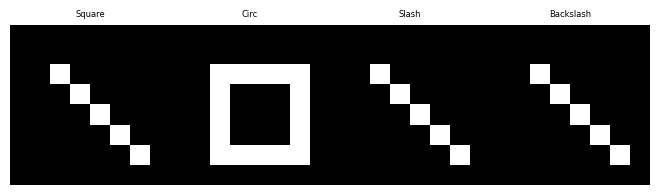

array([<Axes: title={'center': 'Square'}>, <Axes: title={'center': 'Circ'}>, <Axes: title={'center': 'Slash'}>,
       <Axes: title={'center': 'Backslash'}>], dtype=object)

In [301]:

def propagate(M, x):
    x_ = x.flatten()
    p = .5
    zs = (x_ > p).astype(np.int8)
    _y = M @ zs
    y = np.clip(_y.flatten(), 0, 1)
    return y
    
def predictors(M, xx, yy, labels, pp=None, jj=None, debug=False):
    eps = 0.00001
    if pp is None:
        pp = [.1*k for k in range(1,10)]
    ny = len(labels)
    cm = np.zeros((ny, len(pp), M.shape[0], 2, 2), dtype=int)
    ce = np.zeros((ny, M.shape[0]), dtype=float)
    if jj is None:
        jj = range(0, M.shape[0])
    predictors_ = np.array((ny,len(pp), M.shape[0]), dtype=bool)
    zy = propagate_batch(M, xx)
    zy_ = np.clip(zy, eps, 1-eps)
    Zy = np.zeros((ny, M.shape[0]), dtype=float)
    np.add.at(Zy, yy, zy)
    counts = np.bincount(yy, minlength=ny)
    Zy = np.divide(Zy, counts[:, None],
        out=np.zeros_like(Zy, dtype=float),
        where=counts[:, None] > 0
    )
    print(Zy)
    for i in range(0, zy.shape[0]):
        lb = yy[i]
        y = zy[i]
        if debug:
            print(f'{i}:', 'target:', lb, labels[lb], 'y:', y, ':') 

        for k in range(0, len(pp)):
            p = pp[k]
            #np.where(yy[i] > p)[0]
            for j in jj:
                yj = y[j]
                pred = yj>=p
                if pred:
                    for lb_ in range(0, ny):
                        if lb_==lb:
                            cm[lb,k,j,0,0] += 1 #TP 
                            #if debug:
                            #    print('  TP:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb,k,j].tolist())
                        else:
                            cm[lb_,k,j,1,0] += 1  #FP 
                            #if debug:
                            #    print('  FP:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb_,k,j].tolist())
                else:
                    for lb_ in range(0, ny):
                        if lb_==lb:
                            cm[lb,k,j,0,1] += 1  #FN
                            #if debug:
                            #    print('  FN:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb,k,j].tolist())
                        else:
                            cm[lb_,k,j,1,1] += 1  #TN                            
                            #if debug:
                            #    print('  TN:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb_,k,j].tolist())
        for j in jj:
            y_ = zy_[i]
            for lb_ in range(0, ny):
                if lb_==lb:
                    ce[lb_,j] -= math.log(y_[j])
                else:
                    ce[lb_,j] -= math.log(1-y_[j])
    ce /= xx.shape[0]
    acc = np.zeros((ny, len(pp), M.shape[0]), dtype=float)
    prec = np.zeros((ny, len(pp), M.shape[0]),  dtype=float)
    recal = np.zeros((ny, len(pp), M.shape[0]), dtype=float)
    for i in range(0, ny):
        lb = yy[i]
        #if debug:
        #    print( f'{i}:', 'target:',  lb, labels[lb]) 
        for k in range(0, len(pp)):
        #    if debug:
        #        print( f'  {k}: p:', pp[k]) 
            for j in jj:
                acc[lb,k,j] = float(cm[lb,k,j,0,0] + cm[lb,k,j,1,1])/xx_.shape[0]
                n = cm[lb,k,j,0,0] + cm[lb,k,j,1,0]
                prec[lb,k,j] = float(cm[lb,k,j,0,0])/n if n>0 else 0
                n = cm[lb,k,j,0,0] + cm[lb,k,j,0,1]
                recal[lb,k,j] = float(cm[lb,k,j,0,0])/n if n>0 else 0
        #        if debug:
        #            print('    j:', j, 'acc:', acc[lb, k, j],  'prec:', prec[lb, k, j], 'recal:', recal[lb, k, j])

    predictor_pacc = np.argmax(acc, -1)  
    predictor_pprec = np.argmax(prec, -1)  
    predictor_precal = np.argmax(recal, -1)  
    best_pacc = np.max(acc, -1)
    best_pprec = np.max(prec, -1)
    best_precal = np.max(recal, -1)
    
    K = 3
    iacc = np.argsort(acc, -1)[-K:]

    best_acc = np.max(best_pacc, 1)
    best_acc_p = np.argmax(best_pacc, 1)
    L = np.arange(ny)
    predictor_acc = predictor_pacc[L,best_acc_p]
    print(predictor_pacc.shape, best_acc_p.shape, predictor_acc.shape)
    
    best_prec = np.max(best_pprec, 1)
    best_prec_p = np.argmax(best_pprec, 1)
    predictor_prec = predictor_pprec[L,best_prec_p]

    best_recal = np.max(best_precal, 1)
    best_recal_p = np.argmax(best_precal, 1)
    predictor_recal = predictor_precal[L,best_recal_p]

    predictor_ce = np.argmin(ce, 1)
    best_ce = np.min(ce, 1) 


    return {'ny': ny, 'cm': cm, 'pp': pp, 'acc': acc, 'prec': prec, 'recal': recal,
            'predictor_pacc': predictor_pacc, 'predictor_pprec': predictor_pprec, 'predictor_precal': predictor_precal,
            'predictor_acc': predictor_acc, 'predictor_prec': predictor_prec, 'predictor_recal': predictor_recal,
            'best_acc': best_acc, 'best_prec': best_prec, 'best_recal': best_recal,
            'best_pacc': best_pacc, 'best_pprec': best_pprec, 'best_precal': best_precal,
            'best_acc_p': best_acc_p, 'best_prec_p': best_prec_p, 'best_recal_p': best_recal_p,
            'ce': ce, 'predictor_ce': predictor_ce, 'best_ce': best_ce}


xx_ = normalize_all(xx, 2)*3

print(xx.shape, xx_.shape)
for i in range(0, xx_.shape[0]):
    y = propagate(M, xx_[i])
    print(f'{i}:', dd[i]['id'], yy[i], y)

print(yy)
print(labels)
metrics = predictors(M, xx_, yy, labels, pp=[.5], debug=True)

for j in range(0, M.shape[0]):
    print('cm:', j, metrics['cm'][:,0,j].tolist())
#print(metrics['ce'])
print('predictor_acc:', metrics['predictor_acc'].tolist())
for i in range(0, metrics['best_acc'].shape[0]):
    print(labels[i], '; predictor_acc:', metrics['predictor_acc'][i].tolist(), '; best_acc:', metrics['best_acc'][i].tolist())
for i in range(0, metrics['ce'].shape[0]):
    print(labels[i], 'ce:', metrics['ce'][i])
for i in range(0, metrics['ce'].shape[0]):
    print(labels[i], 'predictor_ce:', metrics['predictor_ce'][i], 'best_ce:', metrics['best_ce'][i])
#print(nn.shape)
#print(nn)

predictors = metrics['predictor_acc']
print(predictors)
kernels = [M[i].reshape(xx[0].shape) for i in range(0, predictors.shape[0]) ]
show_imgs(kernels, ncols=min(len(Y), 10), title_size=6, titles=gg)


In [295]:
def propagate(M, x):
    x_ = x.flatten()
    p = .5
    zs = (x_ > p).astype(np.int8)
    _y = M @ zs
    y = np.clip(_y.flatten(), 0, 1)
    return y

def propagate_batch(M, xx, d2=True):
    singleton = False
    if (d2 and xx.ndim == 2) or (not d2 and xx.ndim == 1):
        xx =xx[None, :]
        singleton = True
    xx_ = xx.reshape(xx.shape[0], -1)
    p = .5
    zs = (xx_ > p).astype(np.int8)
    _y = zs @ M.T
    y = np.clip(_y, 0, 1)
    return y if not singleton else y[0] 

print(M.shape, xx_.shape)
z = propagate(M, xx_[0])
print(z)
z = propagate_batch(M, xx_[0])
print(z)
zz = propagate_batch(M, xx_)
print(xx_.shape)
print(zz.shape)
print(zz)

(16, 64) (4, 8, 8)
[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
(4, 8, 8)
(4, 16)
[[0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.]]


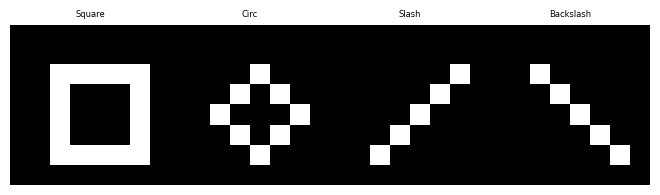

{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'precision_per_class': array([1., 1., 1., 1.]), 'recall_per_class': array([1., 1., 1., 1.]), 'cm': array([[1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])}


In [296]:
def predict(xx, M, metrics, d2=True, predictor='acc'):
    yy = propagate_batch(M, xx, d2=True)
    pred = None
    if predictor=='acc':
        predictor = metrics['predictor_acc']
        p = metrics['best_acc_p']
        #print(predictor)
        #print(yy)
        ny = metrics['ny']
        pred_ = yy[:, predictor]
        pred = np.argmax(pred_, 1)
        #print(pred_)
        #print(pred)
    elif predictor=='ce':
        predictor = metrics['predictor_ce']
    else:
        return None
    return pred

    
def eval(xx, yy, M, metrics, d2=True, predictor='acc'):
    n = 0
    pred = predict(xx, M, metrics, d2, predictor) 
    acc = (pred==yy).mean()
    C = metrics['ny']
    precision_per_class = np.zeros(C)
    recall_per_class = np.zeros(C)
    cm = np.zeros((C, C), dtype=int)
    np.add.at(cm, (yy, pred), 1)
    for i, c in enumerate(range(C)):
        tp = np.sum((pred == c) & (yy == c))
        fp = np.sum((pred == c) & (yy != c))
        fn = np.sum((pred != c) & (yy == c))
        tn = np.sum((pred != c) & (yy != c))
        precision_per_class[i] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall_per_class[i]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    precision = precision_per_class.mean()
    recall    = recall_per_class.mean()
    metrics = {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'cm': cm
    }
    return metrics

pred = predict(xx_, M, metrics)
show_imgs(xx_, ncols=min(pred.shape[0], 10), title_size=6, titles=[gg[pred[i]] for i in range(pred.shape[0])])

metrics_ = eval(xx_, yy, M, metrics)
print(metrics_)

(2, 28, 28)
pca.explained_variance_ratio_: [1.00000000e+00 1.52179488e-31]
pca.singular_values_: [1.53000000e+03 5.96855898e-13]
pca.components_ [[ 3.90101894e-16 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [ 1.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]


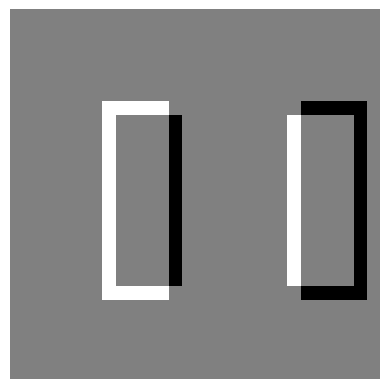

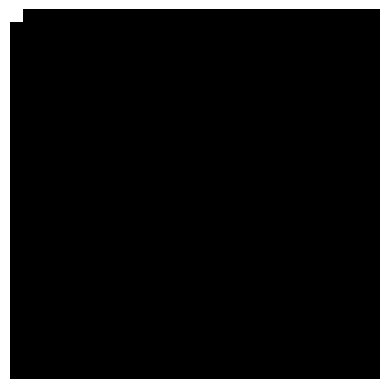

In [188]:
from sklearn.decomposition import PCA

ds = np.array([a, a1]) #, ra
print(ds.shape)
pca = PCA(n_components=2)
pca.fit(ds.reshape(ds.shape[0], -1))

print('pca.explained_variance_ratio_:', pca.explained_variance_ratio_)
print('pca.singular_values_:', pca.singular_values_)
print('pca.components_', pca.components_)
for i in range(0, pca.components_.shape[0]):
    eimg = pca.components_[i].reshape(a.shape)
    show_img(eimg)


In [ ]:
A=Xs__
A_ = A[:, :, None] * A[:, None, :]
print(A.shape, Xs__.shape)

show_imgs(A_, titles=None, ncols=A_.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)
